# BNP Paribas- Bussines Case Project 2025/2026

**Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

# Index

- [1. Import](#import)
  - [1.1 Import libraries](#import-libraries)
  - [1.2 Import the dataset](#import-the-dataset)
- [2. Data Exploration](#data-Exploration)
  - [2.1 MetaData](#metadata)
  - [2.2 Analysing the Data](#Analysing-the-Data)
  - [2.3 Data Visualization](#Data-visualization)
  - [2.4 Correlation Check](#correlation-check)
- [3. Data Quality & Feature Engineering](#Data-Quality-&-Feature-Engineering)
  - [3.1 Data Quality](#Data-Quality)
  - [3.2 Feature Engineering](#Feature-Engineering)
- [4. Implications for Clustering](#Implications-for-Clustering)
  

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


[Back to Index](#index)

<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from suport import *
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   
from sklearn.impute import KNNImputer 

<a class="anchor" id="1.2 Import the Dataset">

## 1.2 Import the Dataset
    
</a>

In [2]:
#pip install pandas pyarrow
#!pip install fastparquet

In [99]:
file_path_CRC = r"C:\Users\jcari\OneDrive\Ambiente de Trabalho\NOVA IMS\Business Cases\Case 1\crc.parquet"
file_path_CREDSCORE = r"C:\Users\jcari\OneDrive\Ambiente de Trabalho\BNP-Paribas-main\credscore.parquet"
file_path_BDOSS = r"C:\Users\jcari\OneDrive\Ambiente de Trabalho\NOVA IMS\Business Cases\Case 1\bdoss.parquet"
file_path_FAMA = r"C:\Users\jcari\OneDrive\Ambiente de Trabalho\BNP-Paribas-main\fama.parquet"

# Ler o ficheiro parquet
CRC = pd.read_parquet(file_path_CRC, engine="fastparquet")
CREDSCORE = pd.read_parquet(file_path_CREDSCORE, engine="fastparquet")
FAMA = pd.read_parquet(file_path_FAMA, engine="fastparquet")
BDOSS = pd.read_parquet(file_path_BDOSS, engine="fastparquet")

file_path = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\crc.parquet"

# Ler o ficheiro parquet
CRC = pd.read_parquet(file_path, engine="fastparquet")

file_path1 = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\credscore.parquet"
CREDSCORE = pd.read_parquet(file_path1, engine="fastparquet")


file_path2 = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\fama.parquet"
FAMA = pd.read_parquet(file_path2, engine="fastparquet")

file_path = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BDOSS.parquet"

# Ler o ficheiro parquet
BDOSS = pd.read_parquet(file_path, engine="fastparquet")

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# 2. Data Exploration
       
</div>


[Back to Index](#index)

<a class="anchor" id="2.1 MetaData">

## 2.1 MetaData

**BDOSS Dataset:**
- *Date_Obs*: Observation Date (MMYY).
- *MT_MENSAL*: Sum of monthly installments paid by the client.
- *COUNT_CL*: Consumer credit count.
- *COUNT_CP*: Credit card or revolving credit count.
- *COUNT_AUTO*:  Auto loan credit count.
- *COUNT_HT*: Mortgage credit count.
- *COUNT_CONEXO*: Connected credit count.
- *COUNT_OTHER*: Other credits count.
- *COUNT_TOTAL*: Total credits count.
- *MONTVENC_CL*:  Sum of overdue amounts in consumer credit. 
- *MONTVENC_CP*:  Sum of overdue amounts in credit card and revolving credit.
- *MONTVENC_AUTO*:  Sum of overdue amounts in auto loans.
- *MONTVENC_HT*:  Sum of overdue amounts in mortgages.
- *MONTABATV_CL*:  Sum of written-off amounts in consumer credit.
- *MONTABATV_CP*:  Sum of written-off amounts in credit card and revolving credit.
- *MONTABATV_AUTO*:  Sum of written-off amounts in auto loans.
- *MONTABATV_HT*:  Sum of written-off amounts in mortgages.
- *DIVIDAS_CL*:   Total consumer credit debt.
- *DIVIDAS_CP*:  Total credit card and revolving credit debt.
- *DIVIDAS_AUTO*: Total auto loan debt.
- *DIVIDAS_HT*: Total mortgage debt.

**CREDSCORE Dataset**:
- *sys_numero_submissao*: Submission number. 
- *sys_data_procura*: Date of risk probing.
- *kp_sqe*: Risk score of known customers based on behavior: A-X, A is better, null= unknown.
- *ks_score_tier*: risk score for granting (all customers) lower is better.

<a class="anchor" id="2.2 Analysing the Data">

## 2.2 Analysing the Data
    
</a>

<a class="anchor" id="2.2.1 CRC">

### 2.2.1. CRC
    
</a>

#### 2.2.1.1. Data Overview

In [5]:
CRC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3034921 entries, 0 to 3034920
Data columns (total 22 columns):
 #   Column          Dtype         
---  ------          -----         
 0   CONTRIB         object        
 1   OBS_DATE        datetime64[ns]
 2   MT_MENSAL       float64       
 3   COUNT_CL        float64       
 4   COUNT_CP        float64       
 5   COUNT_AUTO      float64       
 6   COUNT_HT        float64       
 7   COUNT_CONEXO    float64       
 8   COUNT_OTHER     float64       
 9   COUNT_TOTAL     float64       
 10  MONTVENC_CL     float64       
 11  MONTVENC_CP     float64       
 12  MONTVENC_AUTO   float64       
 13  MONTVENC_HT     float64       
 14  MONTABATV_CL    float64       
 15  MONTABATV_CP    float64       
 16  MONTABATV_AUTO  float64       
 17  MONTABATV_HT    float64       
 18  DIVIDAS_CL      float64       
 19  DIVIDAS_CP      float64       
 20  DIVIDAS_AUTO    float64       
 21  DIVIDAS_HT      float64       
dtypes: datetime64[ns](

- The most important (serious ones) are the MONTABATV. If those variables are too high, the client is not trustworthy.
- It is normal for a client to have DIVIDAS, but is preferable if they reduce month to month.

In [6]:
CRC.describe().round(2)

,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
count,3034921,1029718.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,...,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00
mean,2025-01-01 06:09:42.119141376,552.09,1.65,3.09,0.55,0.46,0.07,0.67,6.49,103.33,...,19.69,37.85,4.34,4.27,0.30,0.47,11438.98,2624.60,5403.67,30449.71
min,2023-12-31 00:00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2024-06-30 00:00:00,236.67,1.00,2.00,0.00,0.00,0.00,0.00,4.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1128.30,132.84,0.00,0.00
50%,2024-12-31 00:00:00,446.60,1.00,3.00,0.00,0.00,0.00,0.00,6.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,6160.02,1133.66,0.00,0.00
75%,2025-06-30 00:00:00,724.99,2.00,4.00,1.00,1.00,0.00,1.00,8.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,15248.11,3219.76,8243.23,46515.51
max,2025-12-31 00:00:00,1224049.39,90.00,183.00,26.00,36.00,15.00,72.00,330.00,2923893.44,...,130756.11,807322.92,171424.67,62861.30,33127.84,288803.22,3194523.32,480181.93,514850.48,4582324.44
std,NaN,1736.58,1.65,2.41,0.76,0.73,0.30,0.88,4.07,2818.38,...,591.92,2541.25,285.17,209.89,59.54,211.27,17905.50,4414.23,9711.06,59607.22


In [7]:
CRC.tail()

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
3034916,fffc5ec9541c7691c7759c637317530910cf44783e4209...,2025-12-31,NaN,3.0,4.0,1.0,1.0,0.0,2.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,11944.76,3285.33,2975.66,76534.61
3034917,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,2025-12-31,990.24,3.0,4.0,0.0,0.0,0.0,1.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,50534.29,1959.59,0.00,0.00
3034918,fffc991d73df732084dab58938d520b8a5d8712474fa53...,2025-12-31,NaN,0.0,2.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00
3034919,fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a...,2025-12-31,NaN,1.0,1.0,1.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2197.85,2213.10,18037.03,0.00
3034920,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2025-12-31,NaN,3.0,1.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,20193.99,3057.11,0.00,0.00


In [8]:
CRC = CRC.sort_values(['CONTRIB', 'OBS_DATE'])

In [9]:
#To each client, check the maximum and minimum number of each variable
CRC.groupby('CONTRIB').agg(['min', 'max'])

OBS_DATE             \
                                                          min        max   
CONTRIB                                                                    
00008246f87bcc3c17b90629bb183fe2e58795176310f01... 2023-12-31 2025-12-31   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349... 2023-12-31 2025-12-31   
0000f858346061c53064586a3347b34659565a6712d004e... 2023-12-31 2025-12-31   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6... 2023-12-31 2025-12-31   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd... 2023-12-31 2025-11-30   
...                                                       ...        ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67... 2023-12-31 2025-12-31   
fffc991d73df732084dab58938d520b8a5d8712474fa539... 2023-12-31 2025-12-31   
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9... 2023-12-31 2025-12-31   
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c... 2023-12-31 2025-12-31   
ffff943c736f98d4840f65328ba372a29689312dd781b43... 2023-12-31 2025-08-31   

                                                   MT_MENSAL           \
                                                         min      max   
CONTRIB                                                                 
00008246f87bcc3c17b90629bb183fe2e58795176310f01...       NaN      NaN   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349...    538.67   547.45   
0000f858346061c53064586a3347b34659565a6712d004e...       NaN      NaN   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6...    515.57   515.57   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd...       NaN      NaN   
...                                                      ...      ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67...    305.96  1031.51   
fffc991d73df732084dab58938d520b8a5d8712474fa539...       NaN      NaN   
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9...       NaN      NaN   
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c...       NaN      NaN   
ffff943c736f98d4840f65328ba372a29689312dd781b43...       NaN      NaN   

                                                   COUNT_CL       COUNT_CP  \
                                                        min   max      min   
CONTRIB                                                                      
00008246f87bcc3c17b90629bb183fe2e58795176310f01...      0.0   1.0      3.0   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349...      4.0  12.0      5.0   
0000f858346061c53064586a3347b34659565a6712d004e...      1.0   2.0      5.0   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6...      3.0   3.0      1.0   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd...      8.0  36.0      3.0   
...                                                     ...   ...      ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67...      1.0   3.0      2.0   
fffc991d73df732084dab58938d520b8a5d8712474fa539...      0.0   1.0      2.0   
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9...      1.0   1.0      1.0   
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c...      2.0   3.0      1.0   
ffff943c736f98d4840f65328ba372a29689312dd781b43...      0.0   1.0      3.0   

                                                         COUNT_AUTO       ...  \
                                                     max        min  max  ...   
CONTRIB                                                                   ...   
00008246f87bcc3c17b90629bb183fe2e58795176310f01...   9.0        0.0  6.0  ...   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349...  15.0        0.0  0.0  ...   
0000f858346061c53064586a3347b34659565a6712d004e...  10.0        1.0  2.0  ...   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6...   2.0        0.0  0.0  ...   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd...  16.0        0.0  0.0  ...   
...                                                  ...        ...  ...  ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67...   8.0        0.0  1.0  ...   
fffc991d73df732084dab58938d520b8a5d8712474fa539...   2.0      

In [10]:
#how many months of data do we have per client
CRC['CONTRIB'].value_counts()

CONTRIB
000785e8aca11cecd0db680ef13a751aa97ccf322d033332c0a4aff8db6e868c    25
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b    25
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981    25
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297    25
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed    25
                                                                    ..
9e8f09117f4ea75b219984761fbdf795ba8e49e669e3d8168f8130bd84bb1b08     1
9e997a7ba95af15492c406601b2973edadd506930affa825ea884cd8d066133a     1
9eaa8e8ad04d65875075ac51063d9e38f2d599fc08d8b6de1e9d802f28281549     1
9ea65350fcbfd95566703782a8e95043445e996aa9e550783c87c25c69d3ad14     1
76859523ebb3d71fa7a5aeb17a43970d0dde5a3800099131d24df5913bd660d3     1
Name: count, Length: 141663, dtype: int64

In [11]:
pd.set_option('display.max_columns', None)
CRC.sort_values(by=['CONTRIB','OBS_DATE'], ascending=False)
CRC.head(26)

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2023-12-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6842.10,963.55,0.00,0.0
119091,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-01-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6782.21,2111.44,0.00,0.0
238477,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-02-29,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6721.85,312.81,0.00,0.0
357730,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-03-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6661.02,501.34,0.00,0.0
477210,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-04-30,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6599.72,997.36,0.00,0.0
597135,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-05-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6537.94,1067.19,0.00,0.0
717015,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-06-30,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8000.00,1729.30,0.00,0.0
837418,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-07-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8000.00,1729.30,0.00,0.0
957821,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-08-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8000.00,1729.30,0.00,0.0
1078224,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-09-30,NaN,0.0,4.0,1.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.65,16000.00,0.0


In [12]:
CRC['DIVIDAS_CL'].value_counts(dropna=False)

DIVIDAS_CL
0.00        567067
5000.00       4716
3000.00       2347
2500.00       2330
10000.00      2130
             ...  
55710.24         1
55039.82         1
54367.68         1
53693.79         1
54388.12         1
Name: count, Length: 1463522, dtype: int64

#### 2.2.1.2. Checking Duplicates

In [13]:
#checking number of duplicates
CRC.duplicated().sum()

np.int64(0)

#### 2.2.1.3. Checking Missing Values

In [14]:
#checking number of missing values
CRC.isna().sum()

CONTRIB                 0
OBS_DATE                0
MT_MENSAL         2005203
COUNT_CL              172
COUNT_CP              172
COUNT_AUTO            172
COUNT_HT              172
COUNT_CONEXO          172
COUNT_OTHER           172
COUNT_TOTAL           172
MONTVENC_CL           172
MONTVENC_CP           172
MONTVENC_AUTO         172
MONTVENC_HT           172
MONTABATV_CL          172
MONTABATV_CP          172
MONTABATV_AUTO        172
MONTABATV_HT          172
DIVIDAS_CL            172
DIVIDAS_CP            172
DIVIDAS_AUTO          172
DIVIDAS_HT            172
dtype: int64

In [15]:
#checking umber of missing values in each column as a percentage
CRC.isna().sum()/len(CRC) * 100

CONTRIB            0.000000
OBS_DATE           0.000000
MT_MENSAL         66.071011
COUNT_CL           0.005667
COUNT_CP           0.005667
COUNT_AUTO         0.005667
COUNT_HT           0.005667
COUNT_CONEXO       0.005667
COUNT_OTHER        0.005667
COUNT_TOTAL        0.005667
MONTVENC_CL        0.005667
MONTVENC_CP        0.005667
MONTVENC_AUTO      0.005667
MONTVENC_HT        0.005667
MONTABATV_CL       0.005667
MONTABATV_CP       0.005667
MONTABATV_AUTO     0.005667
MONTABATV_HT       0.005667
DIVIDAS_CL         0.005667
DIVIDAS_CP         0.005667
DIVIDAS_AUTO       0.005667
DIVIDAS_HT         0.005667
dtype: float64

- MT_MENSAL tem bastantes missing values- provavelmente não é uma variavel que nos vá dar muita informação (mais de 66% é missing value)
- Todas as outras variaveis têm o mesmo numero de missing values que provavelmente pretence às mesmas linhas: pode ser removido

In [16]:
CRC[CRC['COUNT_CL'].isna()]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
120541,03371c474bc2eaf39d5a22222ca6b05a8751a77362b77f...,2024-01-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
479523,04ef89de7d33bab517a2cbdf332dc6bb77f3b8e2561e42...,2024-04-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
719547,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
839950,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
960353,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236966,fcd94d024706a8660a0579a5bfdd1ee254de51123ce35c...,2024-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
836676,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-06-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
957079,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-07-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1077482,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-08-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
CRC[CRC['COUNT_CP'].isna()]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
120541,03371c474bc2eaf39d5a22222ca6b05a8751a77362b77f...,2024-01-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
479523,04ef89de7d33bab517a2cbdf332dc6bb77f3b8e2561e42...,2024-04-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
719547,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
839950,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
960353,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236966,fcd94d024706a8660a0579a5bfdd1ee254de51123ce35c...,2024-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
836676,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-06-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
957079,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-07-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1077482,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-08-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
CRC[CRC['CONTRIB'] == 'c7e93bc661a9d5329ea48d365935197aecff39161303b6bf625189371f7ac23c']

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
92851,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2023-12-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
212165,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-01-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
331418,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-02-29,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
450836,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-03-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
570663,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-04-30,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
690551,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-05-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
810839,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-06-30,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
931242,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-07-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1051645,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-08-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1172696,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-09-30,431.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


There are clients that do not have information about the all 25 months

#### 2.2.1.4. Checking Outliers

In [19]:
metric_features= ['MT_MENSAL', 'COUNT_CL', 'COUNT_CP', 'COUNT_AUTO', 'COUNT_HT', 'COUNT_CONEXO', 'COUNT_OTHER', 'COUNT_TOTAL', 'MONTVENC_CL', 'MONTVENC_CP', 'MONTVENC_AUTO', 'MONTVENC_HT', 'MONTABATV_CL', 'MONTABATV_CP', 'MONTABATV_AUTO', 'MONTABATV_HT', 'DIVIDAS_CL', 'DIVIDAS_CP', 'DIVIDAS_AUTO', 'DIVIDAS_HT']

In [20]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables' Box Plots (>0 only)"):
    
    n_rows = ceil(len(feats) / n_cols)
    
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )
    
    axes = axes.flatten()
    
    for i, feat in enumerate(feats):
        
        # Keep only values strictly greater than 0
        values = data[feat]
        values = values[(values > 0) & (values.notna())]
        
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i])
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no >0 values)", fontsize=10)
    
    # Remove unused subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

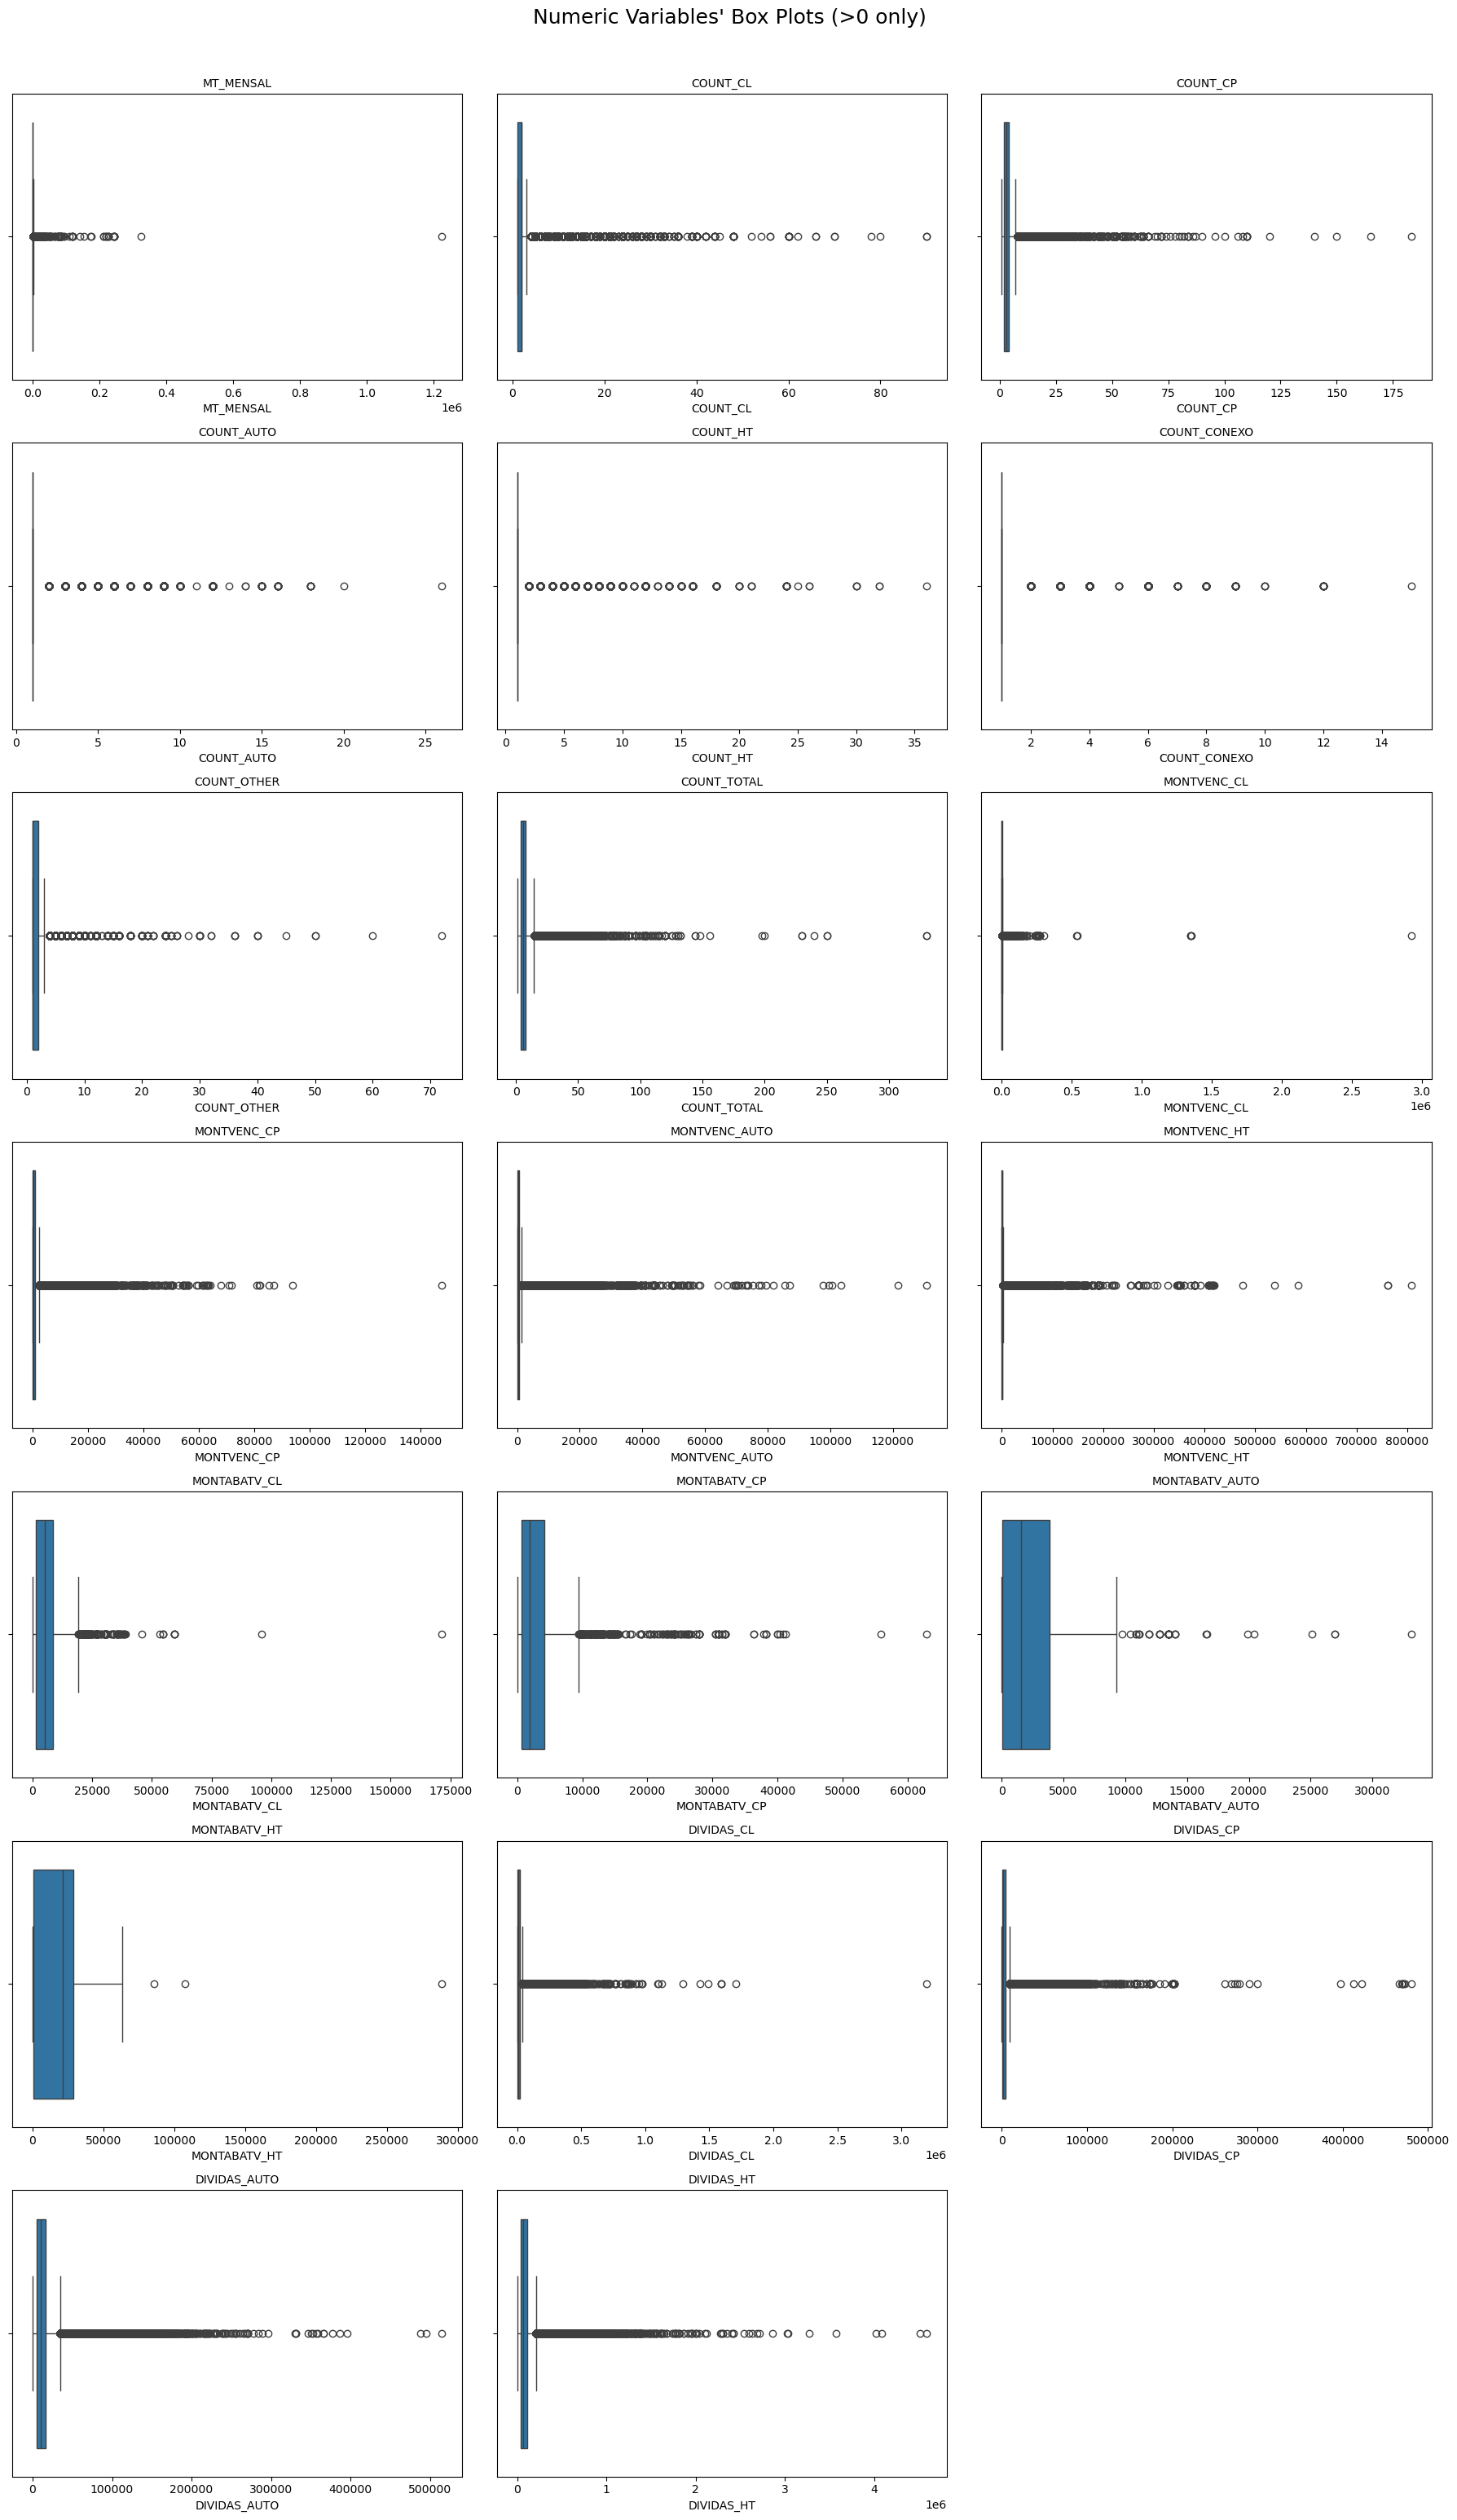

In [21]:
#applying the function to our numerical features
plot_multiple_boxplots(CRC, metric_features)

In [22]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables' Box Plots"):
    
    n_rows = ceil(len(feats) / n_cols)
    
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )
    
    axes = axes.flatten()  # flatten in case of multiple rows
    
    for i, feat in enumerate(feats):
        sns.boxplot(
            x=data[feat],
            ax=axes[i]
        )
        axes[i].set_title(feat, fontsize=10)
    
    # Remove empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

#### 2.2.1.5. Checking Distribution

In [23]:
df= pd.DataFrame(CRC[metric_features])

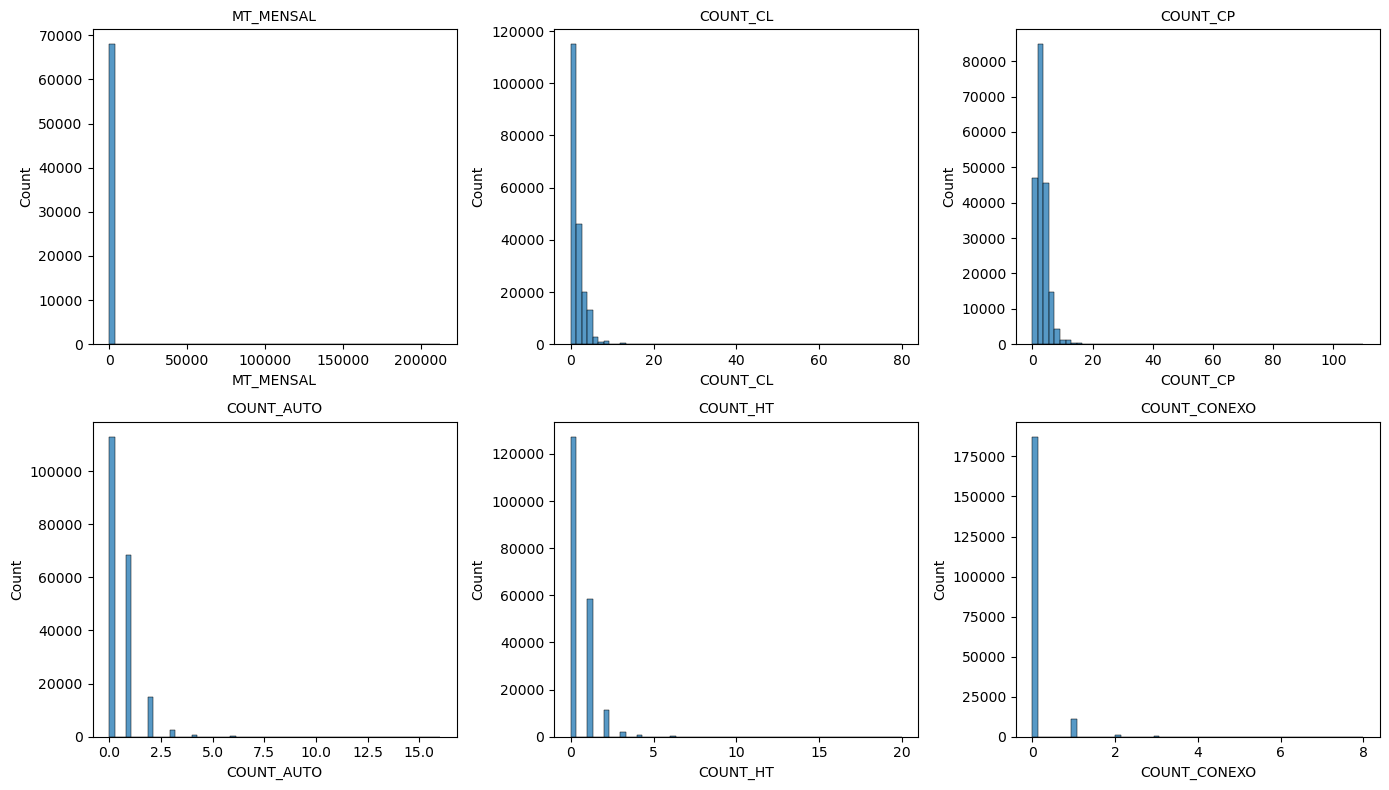

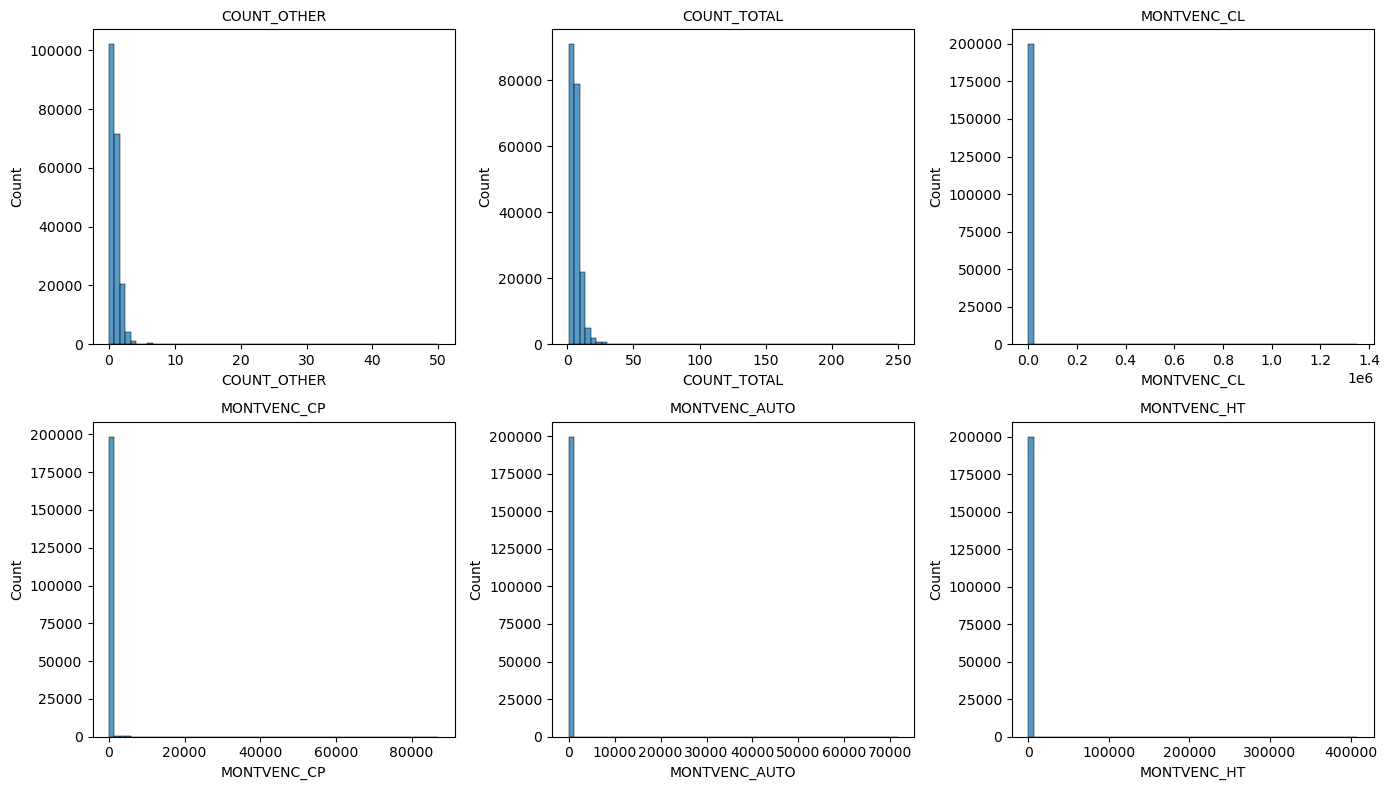

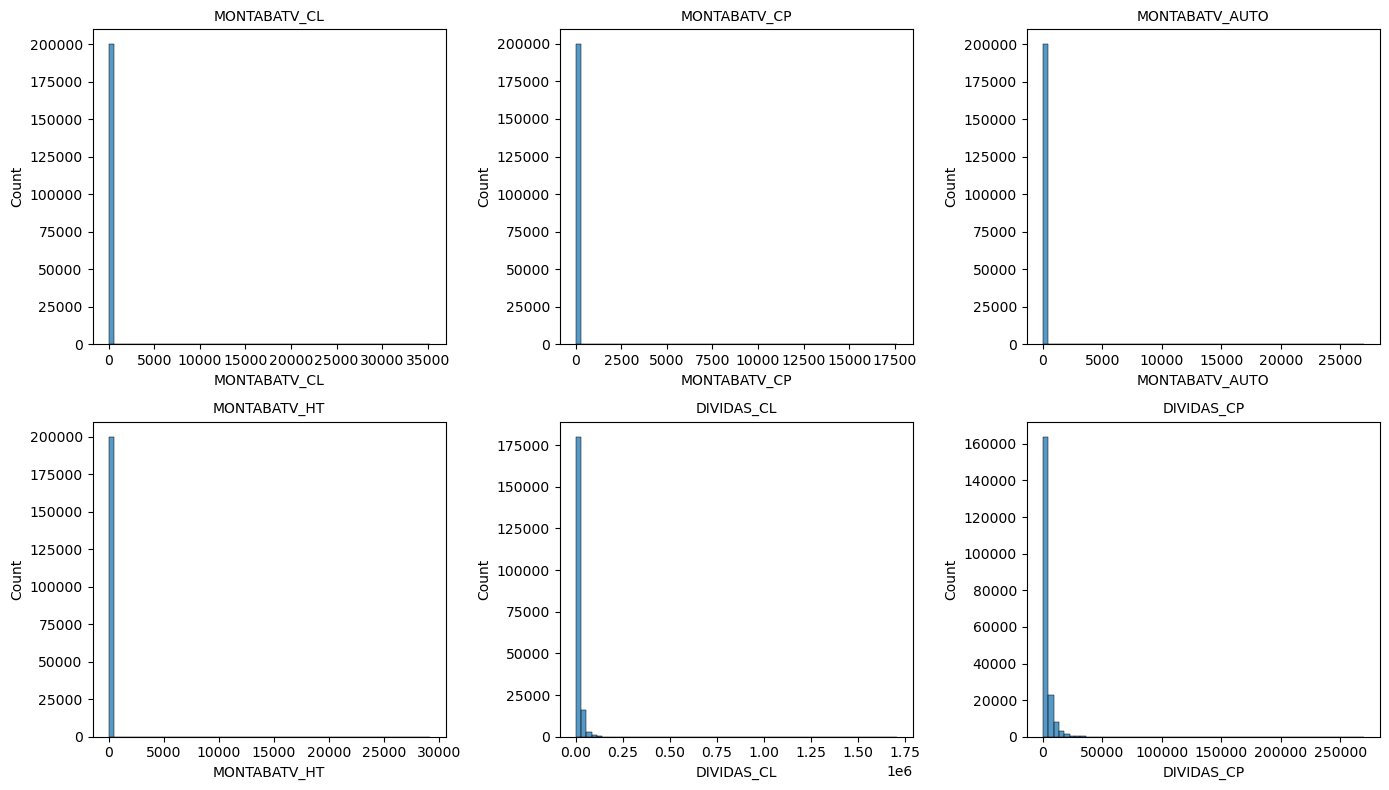

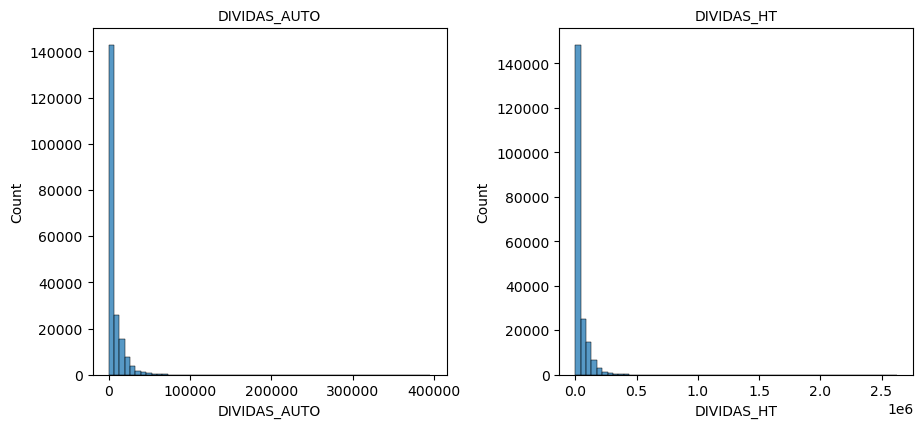

In [24]:
# Sampling
N = 200_000
sample = CRC.sample(n=min(N, len(CRC)), random_state=42)

cols = sample.select_dtypes(include=[np.number]).columns  # all 20 variables

plots_per_fig = 6   # 2 rows x 3 cols
n_figs = ceil(len(cols) / plots_per_fig)

for f in range(n_figs):
    
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    for ax, col in zip(axes, subset_cols):
        sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax)
        ax.set_title(col, fontsize=10)
    
    # Remove empty subplots if last figure has fewer than 6 plots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

#### 2.2.1.6. Checking Correlation between variables

In [25]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = CRC[metric_features].corr(method ='spearman')
cor_spearman

,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
MT_MENSAL,1.000000,0.395456,0.236308,0.231944,0.528161,0.272057,0.236045,0.558835,0.003648,-0.000568,0.016154,0.055819,-0.015057,-0.012127,-0.006622,-0.001455,0.533841,0.253331,0.266549,0.549654
COUNT_CL,0.395456,1.000000,0.204948,-0.183313,-0.006950,0.007571,0.086483,0.508537,0.166407,0.095022,0.025574,0.024357,0.022919,0.009356,-0.000684,0.000307,0.754133,0.321823,-0.153515,-0.014785
COUNT_CP,0.236308,0.204948,1.000000,-0.018989,0.130792,0.048963,0.223728,0.792283,-0.009487,0.065507,-0.021295,-0.004927,-0.006277,0.006749,-0.004314,-0.000484,0.197549,0.578446,-0.012727,0.122814
COUNT_AUTO,0.231944,-0.183313,-0.018989,1.000000,0.013875,0.015116,-0.035781,0.133008,-0.019078,-0.003135,0.136465,-0.001945,-0.001732,0.001956,0.011013,-0.003241,-0.231844,-0.033016,0.949972,0.016585
COUNT_HT,0.528161,-0.006950,0.130792,0.013875,1.000000,0.320383,0.221910,0.369609,-0.055014,-0.045006,-0.036792,0.113256,-0.009013,-0.011366,-0.005470,0.006431,0.014450,0.026859,0.011636,0.960529
COUNT_CONEXO,0.272057,0.007571,0.048963,0.015116,0.320383,1.000000,0.091806,0.195976,-0.018923,-0.018080,-0.010738,0.040709,-0.000477,-0.002240,-0.001672,-0.001178,0.017701,0.034912,0.012127,0.281941
COUNT_OTHER,0.236045,0.086483,0.223728,-0.035781,0.221910,0.091806,1.000000,0.464314,-0.006671,-0.008518,-0.019657,0.027521,-0.001341,0.000122,-0.001632,-0.001998,0.098743,0.129794,-0.035553,0.190432
COUNT_TOTAL,0.558835,0.508537,0.792283,0.133008,0.369609,0.195976,0.464314,1.000000,0.052153,0.069136,0.016794,0.041150,0.003689,0.006556,-0.001466,0.000327,0.398894,0.532123,0.133098,0.338988
MONTVENC_CL,0.003648,0.166407,-0.009487,-0.019078,-0.055014,-0.018923,-0.006671,0.052153,1.000000,0.464612,0.237175,0.113478,0.065208,0.077152,0.017712,0.007293,0.123688,0.078203,-0.017696,-0.055038
MONTVENC_CP,-0.000568,0.095022,0.065507,-0.003135,-0.045006,-0.018080,-0.008518,0.069136,0.464612,1.000000,0.230611,0.095578,0.050279,0.075669,0.011731,0.000846,0.074388,0.167852,-0.002428,-0.044053


In [26]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap='YlGnBu',            #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

'''This function visualises a correlation matrix using a heatmap to
facilitate interpretation of relationships between variables. By 
masking the upper triangle of the matrix, the plot avoids redundant
information and improves the readability. '''

'This function visualises a correlation matrix using a heatmap to\nfacilitate interpretation of relationships between variables. By \nmasking the upper triangle of the matrix, the plot avoids redundant\ninformation and improves the readability. '

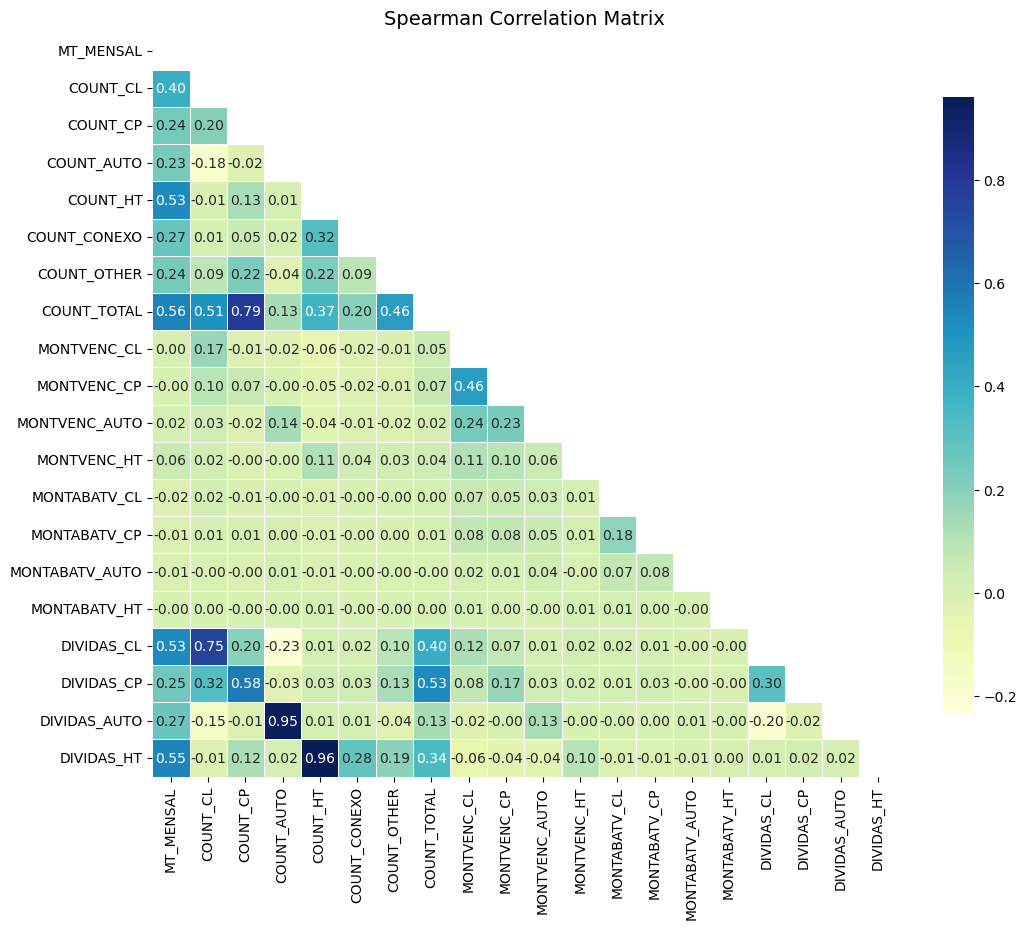

In [27]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

In [28]:
sns.set()

#creating a pairplot for numerical features
sns.pairplot(
    df[metric_features],
    diag_kind="hist"
)
#adjusting the layout and adding a title
plt.subplots_adjust(top=0.95)
plt.suptitle(
    "Pairwise Relationship of Numerical Variables",
    fontsize=20
)

#displaying the plot
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x00000210F19F3B00> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

: 

: 

#### 2.2.1.7. Checking Incoherencies

In [ ]:
CRC[CRC['COUNT_CL'] > CRC['DIVIDAS_CL']]

In [ ]:
CRC[CRC['COUNT_CP'] > CRC['DIVIDAS_CP']]

In [ ]:
CRC[
    CRC['COUNT_CL'] +
    CRC['COUNT_CP'] +
    CRC['COUNT_AUTO'] +
    CRC['COUNT_HT'] +
    CRC['COUNT_CONEXO'] +
    CRC['COUNT_OTHER']
    != CRC['COUNT_TOTAL']
]

### 2.2.1.2. Data Preparation

In [ ]:
CRC.set_index('CONTRIB', inplace = True)

In [ ]:
#Changing Datatypes
CRC['COUNT_CL'] = CRC['COUNT_CL'].round().astype('Int32')
CRC['COUNT_CP'] = CRC['COUNT_CP'].round().astype('Int32')
CRC['COUNT_AUTO'] = CRC['COUNT_AUTO'].round().astype('Int32')
CRC['COUNT_HT'] = CRC['COUNT_HT'].round().astype('Int32')
CRC['COUNT_CONEXO'] = CRC['COUNT_CONEXO'].round().astype('Int32')
CRC['COUNT_OTHER'] = CRC['COUNT_OTHER'].round().astype('Int32')
CRC['COUNT_TOTAL'] = CRC['COUNT_TOTAL'].round().astype('Int32')

In [ ]:
#handling missing values of 172 rows
CRC = CRC.dropna(subset=['COUNT_CL'])

In [ ]:
#droping MT_MENSAL due to its elevated number of missing values
CRC = CRC.drop(columns=['MT_MENSAL'])

In [ ]:
#checking number of missing values
CRC.isna().sum()

### 2.2.1.3. Feature Engineering

In [ ]:
CRC.info()

In [ ]:
#creating 'MONTVENC_TOTAL'
CRC['MONTVENC_TOTAL'] = CRC[
    ['MONTVENC_CL','MONTVENC_CP','MONTVENC_AUTO','MONTVENC_HT']
].sum(axis=1)

In [ ]:
#creating 'MONTABATV_TOTAL'
CRC['MONTABATV_TOTAL'] = CRC[
    ['MONTABATV_CL','MONTABATV_CP','MONTABATV_AUTO','MONTABATV_HT']
].sum(axis=1)

In [ ]:
#has the client default history?
CRC['HIGH_RISK_CURRENT'] = (
    (CRC['MONTABATV_TOTAL'] > 0) | 
    (CRC['MONTVENC_TOTAL'] > 0)
).astype(int)

In [ ]:
CRC['BALANCE_CL'] = (CRC['MONTVENC_CL'] - CRC['MONTABATV_CL'])
CRC['BALANCE_CP'] = (CRC['MONTVENC_CP'] - CRC['MONTABATV_CP'])
CRC['BALANCE_AUTO'] = (CRC['MONTVENC_AUTO'] - CRC['MONTABATV_AUTO'])
CRC['BALANCE_HT'] = (CRC['MONTVENC_HT'] - CRC['MONTABATV_HT'])

cols_to_move = ['BALANCE_CL', 'BALANCE_CP', 'BALANCE_AUTO', 'BALANCE_HT']

for col in reversed(cols_to_move):
    col_data = CRC.pop(col)
    CRC.insert(10, col, col_data)

In [ ]:
#CRC = CRC.drop(columns=['MONTVENC_CL', 'MONTABATV_CL', 'MONTVENC_CP', 'MONTABATV_CP', 'MONTVENC_AUTO', 'MONTABATV_AUTO', 'MONTVENC_HT', 'MONTABATV_HT', 'MONTVENC_TOTAL', 'MONTABATV_TOTAL'])

In [ ]:
pd.set_option('display.max_columns', None)
CRC = CRC.sort_values(['CONTRIB', 'OBS_DATE'])
CRC.tail(30)

In [ ]:
def moda(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan

In [ ]:
#aggregating CRC's variables 
CRC_agg = (
    CRC
    .groupby("CONTRIB", as_index=True)
    .agg(
        count_cl_mean=("COUNT_CL", "mean"),
        count_cl_mode=("COUNT_CL", moda),
        count_cp_mean=("COUNT_CP", "mean"),
        count_cp_mode=("COUNT_CP", moda),
        count_auto_mean=("COUNT_AUTO", "mean"),
        count_auto_mode=("COUNT_AUTO", moda),
        count_ht_mean=("COUNT_HT", "mean"),
        count_ht_mode=("COUNT_HT", moda),
        count_conexo_mean=("COUNT_CONEXO", "mean"),
        count_conexo_mode=("COUNT_CONEXO", moda),
        count_other_mean=("COUNT_OTHER", "mean"),
        count_other_mode=("COUNT_OTHER", moda),
        montvenc_cl_mean= ("MONTVENC_CL", "mean"),
        montvenc_cl_mode= ("MONTVENC_CL", moda),
        montvenc_cp_mean= ("MONTVENC_CP", "mean"),
        montvenc_cp_mode= ("MONTVENC_CP", moda),
        montvenc_auto_mean= ("MONTVENC_AUTO", "mean"),
        montvenc_auto_mode= ("MONTVENC_AUTO", moda),
        montvenc_ht_mean= ("MONTVENC_HT", "mean"),
        montvenc_ht_mode= ("MONTVENC_HT", moda),
        montabatv_cl_mean= ("MONTABATV_CL", "mean"),
        montabatv_cl_mode= ("MONTABATV_CL", moda),
        montabatv_cp_mean= ("MONTABATV_CP", "mean"),
        montabatv_cp_mode= ("MONTABATV_CL", moda),
        montabatv_auto_mean= ("MONTABATV_AUTO", "mean"),
        montabatv_auto_mode= ("MONTABATV_AUTO", moda),
        montabatv_ht_mean= ("MONTABATV_HT", "mean"),
        montabatv_ht_mode= ("MONTABATV_HT", moda),
        balance_cl_mean=("BALANCE_CL", "mean"),
        balance_cl_mode=("BALANCE_CL", moda),
        balance_cp_mean=("BALANCE_CP", "mean"),
        balance_cp_mode=("BALANCE_CP", moda),
        balance_auto_mean=("BALANCE_AUTO", "mean"),
        balance_auto_mode=("BALANCE_AUTO", moda),
        balance_ht_mean=("BALANCE_HT", "mean"),
        balance_ht_mode=("BALANCE_HT", moda),
        dividas_cl_mean=("DIVIDAS_CL", "mean"),
        dividas_cl_mode=("DIVIDAS_CL", moda),
        dividas_cp_mean=("DIVIDAS_CP", "mean"),
        dividas_cp_mode=("DIVIDAS_CP", moda),
        dividas_auto_mean=("DIVIDAS_AUTO", "mean"),
        dividas_auto_mode=("DIVIDAS_AUTO", moda),
        dividas_ht_mean=("DIVIDAS_HT", "mean"),
        dividas_ht_mode=("DIVIDAS_HT", moda),
    )
)

In [ ]:
CRC_agg.head()

In [ ]:
numeric_cols = ['COUNT_CL', 'COUNT_CP', 'COUNT_AUTO', 'COUNT_HT', 'COUNT_CONEXO', 'COUNT_OTHER', 'COUNT_TOTAL', 'MONTVENC_CL', 'MONTVENC_CP', 'MONTVENC_AUTO', 'MONTVENC_HT', 
                'MONTABATV_CL', 'MONTABATV_CP', 'MONTABATV_AUTO', 'MONTABATV_HT', 'DIVIDAS_CL', 'DIVIDAS_CP', 'DIVIDAS_AUTO', 'DIVIDAS_HT']

N = 200_000 
sample = CRC.sample(n=min(N, len(CRC)), random_state=42) 
cols = numeric_cols[:6] 

fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.ravel() 
for ax, col in zip(axes, cols): 
    sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax) 
    ax.set_title(col) 

plt.tight_layout() 
plt.show()

In [ ]:
N = 200_000 
sample = CRC.sample(n=min(N, len(CRC)), random_state=42) 
cols = numeric_cols[7:13] 

fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.ravel() 
for ax, col in zip(axes, cols): 
    sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax) 
    ax.set_title(col) 

plt.tight_layout() 
plt.show()

In [ ]:
N = 200_000 
sample = CRC.sample(n=min(N, len(CRC)), random_state=42) 
cols = numeric_cols[14:20] 

fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.ravel() 
for ax, col in zip(axes, cols): 
   sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax) 
   ax.set_title(col) 

plt.tight_layout() 
plt.show()

In [ ]:
corr = CRC.corr(numeric_only=True)

mask = (corr.abs() < 0.5)

plt.figure(figsize=(12,8))
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            cmap="Blues", 
            center=0)

plt.title("Correlation")
plt.show()

<a class="anchor" id="2.2.2 CREDSCORE">

### 2.2.2 CREDSCORE
    
</a>

#### 2.2.2.1. Data Overview

In [ ]:
CREDSCORE.info()

In [ ]:
CREDSCORE.describe().round(2)

In [ ]:
#descriptive statistics for categorical data
CREDSCORE.describe(include = ['O'])

In [ ]:
#how many clients exists for each classification (Alphabetical order)
CREDSCORE['kp_sqe'] \
    .value_counts(dropna=False) \
    .sort_index()

- We can see the most common classification is 'A' which is a good indicator, and there is no client with classification 'X' (the worst)
- We should see what classification is considered risky

In [ ]:
CREDSCORE['ks_score_tier'].value_counts(dropna=False)

- The most common one is 1, which is also a good indicator.

#### 2.2.2.2. Checking Duplicates

In [ ]:
#checking number of duplicates
CREDSCORE.duplicated().sum()

In [ ]:
dups = CREDSCORE[CREDSCORE.duplicated(subset=["CONTRIB"], keep=False)].sort_values("CONTRIB")
display(dups.head(20))

In [ ]:
CREDSCORE = CREDSCORE.sort_values(['CONTRIB'])

In [ ]:
import pandas as pd

# Show all columns
pd.set_option('display.max_columns', None)

# Show full content of each column (no truncation)
pd.set_option('display.max_colwidth', None)

# Optional: increase display width for better readability
pd.set_option('display.width', 200)

# Display the first 10 duplicated rows sorted by 'CONTRIB'
duplicated_rows = CREDSCORE[CREDSCORE.duplicated()]
duplicated_rows.sort_values(['CONTRIB']).head(10)

In [ ]:
print("shape:", CREDSCORE.shape)
print("clientes únicos:", CREDSCORE['CONTRIB'].nunique())
print("duplicados por cliente:", CREDSCORE.duplicated(subset=['CONTRIB']).sum())

há 700 duplicados no contribuinte

In [ ]:
CREDSCORE['sys_data_procura'] = pd.to_datetime(CREDSCORE['sys_data_procura'], errors='coerce')

# número de datas diferentes por cliente
dates_per_client = CREDSCORE.groupby('CONTRIB')['sys_data_procura'].nunique()

print("Clientes com >1 data:", (dates_per_client > 1).sum())

106 clientes têm mais que uma data, ou seja tiveram o score calculado mais que uma vez

In [ ]:
CREDSCORE[CREDSCORE['CONTRIB']=='0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557']

#### 2.2.2.3. Checking Missing Values

In [ ]:
CREDSCORE['kp_sqe'] = CREDSCORE['kp_sqe'].astype(str).str.strip().str.upper()
CREDSCORE['kp_sqe'] = CREDSCORE['kp_sqe'].replace({'NULL': np.nan, 'NONE': np.nan})

In [ ]:
#checking umber of missing values in each column as a percentage
CREDSCORE.isna().sum()/len(CREDSCORE) * 100

In [ ]:
#checking number of missing values
CREDSCORE.isna().sum()

#### 2.2.2.4. Checking Outliers

In [ ]:
metric_features= ['ks_score_tier']

In [ ]:
#applying the function to our numerical features
plot_multiple_boxplots(CREDSCORE, metric_features)

#### 2.2.2.5. Checking Distribution

##### 2.2.2.5.1. Numerical Variables

In [ ]:
df= pd.DataFrame(CREDSCORE[metric_features])

In [ ]:
# Sampling
N = min(200_000, len(CREDSCORE))
sample = CREDSCORE.sample(n=N, random_state=42)

col = metric_features[0]   # 'ks_score_tier'

fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax)

ax.set_title(col, fontsize=12)
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

##### 2.2.2.5.2. Categorical Variables

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set white background style
sns.set_style('white')

# Function to generate a palette based on number of unique categories
def get_palette(CREDSCORE, column):
    n = CREDSCORE[column].nunique()
    return sns.color_palette("tab20", n) if n <= 20 else sns.color_palette("husl", n)

# Specify the variable to plot
column_to_plot = 'kp_sqe'  # replace with your actual column name

# Generate palette
palette = get_palette(CREDSCORE, column_to_plot)

# Create figure
plt.figure(dpi=300, figsize=(12, 6))
plt.gcf().patch.set_facecolor('white')

# Create count plot
sns.countplot(
    data=CREDSCORE,
    x=column_to_plot,
    hue=column_to_plot,
    palette=palette,
    dodge=False
)

# Rotate x-axis labels for readability
plt.xticks(rotation=90)

# Remove legend (optional)
plt.legend([],[], frameon=False)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

### 2.2.2.2. Data Preparation

In [ ]:
# remover colunas técnicas
CREDSCORE = CREDSCORE.drop(columns=['sys_numero_submissao','sys_hora_procura'], errors='ignore')

In [ ]:
CREDSCORE = CREDSCORE.sort_values(['CONTRIB','sys_data_procura'])
CREDSCORE = CREDSCORE.groupby('CONTRIB', as_index=False).tail(1)

In [ ]:
print("shape:", CREDSCORE.shape)
print("clientes únicos:", CREDSCORE['CONTRIB'].nunique())
print("duplicados por cliente:", CREDSCORE.duplicated(subset=['CONTRIB']).sum())

ficamos apenas com a última linha de cada cliente
a variável 'kp_sqe' tem 

In [ ]:
CREDSCORE.groupby(CREDSCORE['kp_sqe'].isna())['ks_score_tier'].describe()

Para analisar o 'ks_score_tier' dos valores com e sem 'kp_sqe' (true é com missing value)

Em média os clientes com missing values têm média do score mais alto, ou seja risco mais elevado (como a empresa tem menos confiança neles assume maior incerteza e score pior, faz sentido)

In [ ]:
#droping duplicate rows 
CREDSCORE = CREDSCORE.drop_duplicates()

In [ ]:
for col in CREDSCORE.columns:
    print(f"'{col}'")

In [ ]:
CREDSCORE['sys_data_procura'] = pd.to_datetime(CREDSCORE['sys_data_procura'])

CREDSCORE = CREDSCORE.loc[
    CREDSCORE.groupby('CONTRIB')['sys_data_procura'].idxmax()
]

print(CREDSCORE)

In [ ]:
#filling missing values
CREDSCORE['kp_sqe'] = CREDSCORE['kp_sqe'].fillna('NO_BEHAVIOR_HISTORY')

In [ ]:
#creating is_risky 
CREDSCORE['is_risky'] = (
    (CREDSCORE['kp_sqe'] > 'D') |
    (CREDSCORE['ks_score_tier'] > 2)
)

In [ ]:
CREDSCORE['is_risky'].value_counts(dropna=False)

In [ ]:
CREDSCORE.head()

<a class="anchor" id="2.2.3 FAMA">

## 2.2.3 FAMA
    
</a>

#### 2.2.3.1. Data Overview

Neste dataset vamos olhar para o historico do cliente e nao para o que esta ativo.

In [ ]:
FAMA.info()

In [ ]:
num_cols = FAMA.select_dtypes(include=['number']).columns
obj_cols = FAMA.select_dtypes(include=['object']).columns

print("Numéricas:", len(num_cols))
print("Categóricas:", len(obj_cols))

In [ ]:
pd.set_option('display.max_columns', None)
FAMA.head()

In [ ]:
FAMA.describe().T

In [ ]:
#descriptive statistics for categorical data
FAMA.describe(include = ['O'])

In [ ]:
FAMA.shape

In [ ]:
FAMA['CONTRIB'].nunique()

In [ ]:
FAMA['sdem_SITFAM'].value_counts(dropna=False)

- There are a large number of married (C), other (X), single (S) and cohabiting (U) people. 
- The least common are widowed

In [ ]:
FAMA['sdem_HABITAT'].value_counts(dropna=False)

- Most people have access to property (loan), are housed by family and owned or rent a house.
- The least common is 'other' and housed by the employer.

#### 2.2.3.2. Checking Duplicates

In [ ]:
#checking number of duplicates
FAMA.duplicated().sum()

#### 2.2.3.3. Checking Missing Values

In [ ]:
#checking number of missing values
FAMA.isna().sum()

#### 2.2.3.4. Checking Outliers

In [ ]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables' Box Plots (>0 only)"):
    
    n_rows = ceil(len(feats) / n_cols)
    
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )
    
    axes = axes.flatten()
    
    for i, feat in enumerate(feats):
        
        # Keep only values strictly greater than 0
        values = data[feat]
        values = values[(values > 0) & (values.notna())]
        
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i])
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no >0 values)", fontsize=10)
    
    # Remove unused subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [ ]:
plot_multiple_boxplots(FAMA, num_cols)

#### 2.2.3.5. Checking Distribution

#### 2.2.3.6. Checking Correlation between variables

In [ ]:
num_cols = FAMA.select_dtypes(include='number').columns

corr = FAMA[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation matrix - FAMA")
plt.show()

In [ ]:
# Highly correlated variables (|ρ| > 0.9) will be identified to avoid redundancy
high_corr = np.where(np.abs(corr) > 0.9)

for i,j in zip(*high_corr):
    if i < j:
        print(corr.index[i], "<->", corr.columns[j], corr.iloc[i,j])

Retirar "ALLBD_N_events__N" e "ALLBD_max_active_resso__N"

"ALLBD_MTFIN_CL__N" e "ALLBD_MTFINO_CL__N" são quase redundantes mas vão servir para criar uma variavel, depois podemos tirar

### 2.2.3.2. Data Preparation

In [ ]:
# proporção de créditos ativos

FAMA["active_credit_ratio"] = (
    FAMA["ALLBD_A_CL__N"] + FAMA["ALLBD_A_CP__N"]
) / (
    FAMA["ALLBD_N_CL__N"] + FAMA["ALLBD_N_CP__N"] + 1
)

0 -> nenhum credito ativo

1 -> todos os créditos estão ativos

In [ ]:
# carga financeira (montante de crédito vs rendimento)
FAMA["debt_income_ratio"] = (
    FAMA["ALLBD_MTFIN_CL__N"] /
    (FAMA["ALLBD_mean_active_resso__N"] + 1)
)

In [ ]:
# ratio de progresso do crédito

FAMA["credit_progress"] = (
    FAMA["ALLBD_MTFIN_CL__N "] /
    (FAMA["ALLBD_MTFINO_CL__N "] + 1)
)

In [ ]:
# percentagem de credito por pagar

FAMA["credit_remaining_ratio"] = (
    FAMA["ALLBD_MTFIN_CL__N"] /
    (FAMA["ALLBD_MTFINO_CL__N"] + 1)
)

In [ ]:
drop=['ALLBD_A_CL__N','ALLBD_A_CP__N','ALLBD_MTFIN_CL__N','ALLBD_MTFIN_CP__N']
drop1=['ALLBD_IDADE_MSA__N','ALLBD_IDADE_MIN__N']
FAMA= FAMA.drop(columns=drop1, errors='ignore')

In [ ]:
FAMA.head()

In [ ]:
x = (FAMA['ALLBD_mean_active_resso__N'] != FAMA['ALLBD_max_active_resso__N']).mean() * 100
x

<a class="anchor" id="2.2.4 BDOSS">

### 2.2.4 BDOSS
    
</a>

#### 2.2.4.1. Data Overview

In [100]:
pd.set_option('display.max_columns', None)
BDOSS.head()

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,P,CL,EP,0.0,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.0,69.0,69.0,20000.0,20000.0,347.447280,NaN,13208.455,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1113.258,80.0,1988.0,P,2845,1.0,A
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,P,CL,EP,0.0,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72.0,34.0,34.0,2500.0,2500.0,56.017772,NaN,0.000,0.000,NaN,1.0,1.0,000000000000210210000110,0.0,120.0,N,838.186,91.0,1990.0,P,2855,0.0,A
2,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,P,CL,EP,0.0,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84.0,52.0,52.0,5000.0,5000.0,100.073575,NaN,2665.191,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,1314.144,80.0,2013.0,P,2635,2.0,W
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,446d96905d26356fb4f1d3e1e6da3868b8106b09a558e6...,P,CL,EPF,0.0,ENC,2024-01-31,2023-01-09,2023-01-13,2023-01-13,2023-01-13,60.0,13.0,37.0,6000.0,6000.0,162.097525,NaN,5893.092,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,117.0,P,1031.650,80.0,1989.0,P,5090,0.0,A
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,N,CL,EXT,0.0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84.0,32.0,32.0,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112122,0.0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A


In [101]:
BDOSS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658187 entries, 0 to 2658186
Data columns (total 35 columns):
 #   Column             Dtype         
---  ------             -----         
 0   CONTRIB            object        
 1   DOSSIER            object        
 2   POLE               object        
 3   TYPEPROD           object        
 4   PRODALP            object        
 5   BICONTRATO         float64       
 6   POS                object        
 7   OBS_DATE           datetime64[ns]
 8   DCREAT             datetime64[ns]
 9   DATFIN             datetime64[ns]
 10  D1FIN              datetime64[ns]
 11  DPOS               datetime64[ns]
 12  DURDEG             float64       
 13  RANGPRO            float64       
 14  RANGCLI            float64       
 15  MTFINO             float64       
 16  MTFIN              float64       
 17  MENSALIDADE        float64       
 18  MENSALIDADE_CORR   float64       
 19  CRD                float64       
 20  SREC               float

In [102]:
BDOSS['BICONTRATO'] = BDOSS['BICONTRATO'].round().astype('Int32')
BDOSS['DURDEG'] = BDOSS['DURDEG'].round().astype('Int32')
BDOSS['RANGPRO'] = BDOSS['RANGPRO'].round().astype('Int32')
BDOSS['RANGCLI'] = BDOSS['RANGCLI'].round().astype('Int32')
BDOSS['RISKA'] = BDOSS['RISKA'].round().astype('Int32')

In [103]:
BDOSS.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
CONTRIB,2658187,148729,364aad4f1733591b129753f295cca317a449f207c209bd...,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOSSIER,2658187,185592,f8908577ee5bab0f764f1f007f439370b0511585b89d96...,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POLE,2658187,2,P,2615205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPEPROD,2658187,1,CL,2658187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRODALP,2658187,4,EP,1912612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BICONTRATO,2658187.0,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0
POS,2658187,4,ENC,2214397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OBS_DATE,2658187,NaN,NaN,NaN,2024-12-31 12:04:59.079635456,2024-01-31 00:00:00,2024-06-30 00:00:00,2024-12-31 00:00:00,2025-06-30 00:00:00,2025-11-30 00:00:00,NaN
DCREAT,2658187,NaN,NaN,NaN,2022-03-23 09:42:27.446511104,1996-06-14 00:00:00,2020-11-24 00:00:00,2022-10-20 00:00:00,2024-01-31 00:00:00,2025-12-02 00:00:00,NaN
DATFIN,2658187,NaN,NaN,NaN,2022-04-01 11:27:02.187001088,1996-06-17 00:00:00,2020-12-02 00:00:00,2022-10-28 00:00:00,2024-02-07 00:00:00,2025-12-02 00:00:00,NaN


#### 2.2.4.2. Checking Duplicates

In [104]:
BDOSS.duplicated().sum()

np.int64(0)

#### 2.2.4.3. Checking Missing Values

In [105]:
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]

RANGCLI                    1
MENSALIDADE_CORR     2658187
ACTIVIDADE_GLOBAL    2658187
DCSP                  293663
NATIO                      1
NBENF                    736
MODCONTACTO            59544
dtype: int64

In [106]:
#checking number of missing values in each column as a percentage
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]/len(BDOSS) * 100

RANGCLI                0.000038
MENSALIDADE_CORR     100.000000
ACTIVIDADE_GLOBAL    100.000000
DCSP                  11.047492
NATIO                  0.000038
NBENF                  0.027688
MODCONTACTO            2.240023
dtype: float64

**- Constant Features**

In [107]:
BDOSS['MENSALIDADE_CORR'].unique()

array([nan])

In [108]:
BDOSS['ACTIVIDADE_GLOBAL'].unique()

array([nan])

In [109]:
BDOSS['TYPEPROD'].unique()

array(['CL'], dtype=object)

In [110]:
BDOSS['BICONTRATO'].unique()

<IntegerArray>
[0]
Length: 1, dtype: Int32

**- more data analysis**

In [111]:
BDOSS['RISK'].value_counts()

RISK
000000000000000000000000    2327930
444444444444444444444444      23863
000000000000000000000001      16652
000000000000000000000010       7487
000000000000000000000100       6278
                             ...   
010000100001000111122010          1
000000100000000010101010          1
012222222122221221111221          1
000001122222221221122100          1
000110210110000000211221          1
Name: count, Length: 77475, dtype: int64

In [112]:
BDOSS['RISKA'].value_counts()

RISKA
0    2571156
1      79077
7       7954
Name: count, dtype: Int64

In [113]:
BDOSS['NBENF'].value_counts() 

NBENF
0.0     1538648
1.0      664154
2.0      385790
3.0       59785
4.0        7713
5.0        1288
8.0          23
7.0          23
10.0         11
52.0          8
6.0           6
90.0          2
Name: count, dtype: int64

In [114]:
BDOSS['AGFIN'].value_counts()

AGFIN
118.0    1229325
117.0     720161
120.0     518201
119.0     146805
525.0      39560
112.0       3963
111.0         66
500.0         48
503.0         46
116.0          6
100.0          6
Name: count, dtype: int64

In [115]:
BDOSS['POS'].unique()

array(['ENC', 'SAN', 'SOL', 'RBT'], dtype=object)

Meanings of POS's unique values:
- ENC: Normal state;
- SAN: Client settles before date;
- SOL: Client settles on contract termination date;
- RBT: Same as SAN (business wise).

Since RBT is the same as SAN, we will update our dataset so that every RBT turns into SAN.

In [116]:
BDOSS['POS'] = BDOSS['POS'].replace('RBT', 'SAN')

In [117]:
BDOSS['RN'].value_counts()

RN
0.0    2270299
1.0     257370
2.0      88703
3.0      34114
4.0       6707
5.0        970
6.0         24
Name: count, dtype: int64

RN is a red flag feature, the higher it's value, the higher the chance a client will churn.

In [118]:
BDOSS['POLE'].value_counts()

POLE
P    2615205
N      42982
Name: count, dtype: int64

Not specified in MetaData, however, we were told that:
- P: Direct business;
- N: Sales for business partners.

#### 2.2.1.4. Checking Incoherencies

**- PRODALP**

In [119]:
BDOSS['PRODALP'].unique()

array(['EP', 'EPF', 'EXT', 'DEF'], dtype=object)

None of these unique values appear in our MetaData. However, we were told that:
- EP - most used when the clients want to churn; 
- EXT, EPF, DEF: Personal loans.

**- CSP**

In [120]:
BDOSS['CSP'].unique()

array([80., 91., 35., 60., 90., 54., 70., 31., 74., 20., 58., 15., 41.,
       10., 50., 33., 56., 55., 86., 32., 30., 92., 57., 52., 53., 34.,
       40., 81., 99.,  0., 96., 25., 51.])

The values 54, 58, 50, 56, 55, 57, 52, 53, 0 and 51 also don't appear in our MetaData.

In [121]:
missing = [54, 58, 50, 56, 55, 57, 52, 53, 0, 51]
result = 0
for num in BDOSS['CSP']:
    if num in missing:
        result = result + 1
print(result)

161453


In [122]:
result / len(BDOSS['CSP']) * 100

6.073801429320059

These values correspond to around 6% of our data

**- RISK AND RISKA**

In [123]:
BDOSS[BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,N,CL,EXT,0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84,32,32,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112122,0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A
53,00245abdde6b5be044bd121c4618fdcc43e90f9f0ef5bc...,64f6c53b0b8e111e029da5ea073196dbd89ae6025fd9a7...,P,CL,EP,0,SAN,2024-01-31,2022-12-29,2023-01-05,2023-01-05,2023-12-11,22,11,11,2500.0,2500.0,147.925036,NaN,0.000,0.000,NaN,1.0,3.0,000000000000020000101011,0,118.0,P,1451.493,80.0,2021.0,D,8125,2.0,W
57,0026b5f0de9828ec21d97c586dc791fb0671a0224617d1...,2b075e5032a850f4290d1b23e68320cd36cffb93f7dcc8...,P,CL,EP,0,SAN,2024-01-31,2022-02-02,2022-02-03,2022-02-03,2023-06-05,60,16,37,2500.0,2500.0,61.538164,NaN,0.000,0.000,NaN,3.0,9.0,000000002110122200122001,0,118.0,P,2009.717,10.0,2018.0,P,3090,2.0,W
72,002ddf74dace98336bfd869bdf44deab63ab07753122d6...,2a0c6243fee831fa936fc507b331b614dc6ad6b53910d6...,P,CL,EP,0,SOL,2024-01-31,2014-01-09,2014-01-22,2014-01-09,2022-10-04,84,81,81,5000.0,5000.0,118.518615,NaN,0.000,0.000,NaN,3.0,5.0,221111222112012212220111,0,119.0,P,1231.996,70.0,2009.0,P,7580,0.0,T
122,004cc9fa8892482a26231071d03ecb17c5a8779b683804...,56ca44ed01b953656bd0b46454b894de6b39d882e52279...,P,CL,EXT,0,ENC,2024-01-31,2023-04-26,2023-05-08,2023-05-05,2024-01-23,84,9,9,10343.0,10343.0,233.912421,NaN,11549.523,0.000,NaN,0.0,0.0,000000000000000000010110,1,118.0,P,2523.423,35.0,2009.0,P,2775,2.0,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658123,ffddc57160d56f6899d2daa5e1a1720b5903a6e665354f...,c56d1af3fdeeceb79806b8dd25b0495f25f225b5428e88...,P,CL,EPF,0,ENC,2025-11-30,2022-01-09,2022-02-16,2022-02-16,2024-09-09,84,45,45,5000.0,5000.0,107.643659,NaN,3307.841,0.000,NaN,0.0,0.0,000010000000000000000000,1,118.0,P,313.084,52.0,NaN,P,2415,0.0,W
2658149,ffec38e28088b6290ec9ed851675f19b0182cecd14a105...,7bcb4d654fd5736dcc83846e861dfb7b2fab4b21bf7180...,P,CL,EPF,0,ENC,2025-11-30,2022-10-06,2022-10-14,2022-10-14,2025-11-28,84,38,38,11000.0,11000.0,244.084787,NaN,8467.150,0.000,NaN,0.0,0.0,000000000010001000000101,0,117.0,P,861.102,80.0,2000.0,P,3720,0.0,A
2658180,fffa9b9225bff7296ad890805ea9ccf9a105663acb1a97...,9638a80107e20c8cbf33e66fe0ffc642fee561907852dc...,P,CL,EXT,0,SAN,2025-11-30,2023-08-01,2023-08-21,2023-08-18,2025-08-12,84,23,23,24750.0,24750.0,584.152276,NaN,0.000,0.000,NaN,0.0,0.0,000000000000000001111111,0,118.0,P,1253.882,80.0,1995.0,P,4425,1.0,W
2658183,fffbc66ca4256976c9932916770f1ff3b23aacce5998ff...,dea39098d015a030ea0b3ead87c82ccca9137f784f86c7...,P,CL,EPF,0,ENC,2025-11-30,2018-12-21,2018-12-24,2018-12-24,2025-11-28,84,83,83,7430.0,7430.0,157.667572,NaN,137.403,-157.668,NaN,1.0,2.0,000000000000002001111112,0,118.0,P,977.381,31.0,2018.0,P,4820,1.0,W


In [124]:
168528 / len(BDOSS) * 100

6.339960281199178

Here, we can see that only around 6% of our data has a RISKA value diferent than the last number of RISK.

In [125]:
mask = BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)

BDOSS.loc[mask, 'RISK'] = (BDOSS.loc[mask, 'RISK'].astype(str).str[:-1] + 
                           BDOSS.loc[mask, 'RISKA'].astype(str))

BDOSS[BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO


As we can see from the cell above, every one of those referenced entries were corrected so that every RISKA value corresponds to the last number of it's respective RISK value.

**- RANGPRO AND DURDEG**

In [126]:
BDOSS[BDOSS['RANGPRO'] - BDOSS['DURDEG'] > 0]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
13373,1eeda66678fe87887b4e435aa1ac405c4ee922ad6bed98...,6a73d420a9c4629486e6f5dda41f27e14de45734f835ab...,P,CL,EP,0,SOL,2024-01-31,2017-09-14,2017-09-21,2017-09-21,2023-12-01,72,73,73,7000.00,7000.00,157.190164,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,1181.441,70.0,1987.0,P,2350,0.0,A
14809,22535d3248147b8e894c46602e349876a2b7a58252a7b0...,d55babf7dbe197586e7b624efb0da2d1898a90f918b7ac...,P,CL,EPF,0,SOL,2024-01-31,2015-05-22,2015-05-28,2015-05-22,2023-08-04,84,85,85,9000.46,9000.46,199.519797,NaN,0.0,0.0,NaN,1.0,1.0,100000000000000121212120,0,118.0,N,1851.117,90.0,2000.0,P,3610,1.0,None
23704,366d5bd958989f93f6e20d957959f964ddf065149bd715...,7e205ecd82246afc84cc94105be457755e0fe7ccd65b2f...,P,CL,EPF,0,SOL,2024-01-31,2016-08-08,2016-08-23,2016-08-08,2023-11-21,84,85,85,10500.00,10500.00,238.839973,NaN,0.0,0.0,NaN,1.0,0.0,000000110100200111000010,0,117.0,P,901.600,70.0,2012.0,P,2410,1.0,None
48850,7013a45ea15ab41a281691a85a99c53bb650d7b6d12745...,e0cfdfb6402b13a9540add0d348ad1d166ff5de5b99d1f...,P,CL,EPF,0,SOL,2024-01-31,2016-10-14,2016-10-24,2016-10-14,2024-01-01,84,85,85,15000.60,15000.60,341.476332,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000001000000,0,117.0,P,836.839,80.0,1993.0,P,7370,0.0,None
53702,7b2db95efe1f3f55ae0566731a18ef153f7ada276c4fc3...,7c2e2cb7b349743596bd6087f9b55d20d0d2ffae927505...,P,CL,EP,0,SOL,2024-01-31,2017-10-03,2017-10-09,2017-10-09,2024-01-01,72,73,73,15000.00,15000.00,344.638483,NaN,0.0,0.0,NaN,0.0,0.0,000000000000010000000000,0,118.0,P,1045.234,60.0,2012.0,P,2675,0.0,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2591774,747283c8dd6c2be7c5e4d86c4adcd653c3f9381b4f0e6a...,66bb8e8c16bac641e2ff3f1cfbb4f760c310ae3c652d9e...,P,CL,EP,0,SOL,2025-11-30,2017-05-06,2017-07-12,2017-07-12,2025-09-10,96,97,97,25000.00,25000.00,476.003055,NaN,0.0,0.0,NaN,1.0,2.0,002210000000000000002210,0,118.0,P,2710.636,81.0,2016.0,P,2430,2.0,W
2592547,761e197ef3212fef89be1a88eb9d46d862c72e699dc9f6...,91f180eb8d37733c4bd4a1c1f40cce541a84039790e78d...,P,CL,EP,0,SOL,2025-11-30,2019-07-02,2019-07-08,2019-07-08,2025-10-01,72,73,73,11000.00,11000.00,248.800673,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0,120.0,P,662.454,20.0,2015.0,P,4500,2.0,A
2595126,7b4ae59459f74157e8dd76f2cb2a4418dae8818d89758c...,735d4904fb0d6a5daf2298cd7a3f1c6d2e419fc470ea3c...,P,CL,EP,0,SOL,2025-11-30,2023-08-31,2023-08-31,2023-08-31,2025-09-05,24,25,25,4000.00,4000.00,215.810828,NaN,0.0,0.0,NaN,2.0,7.0,020000000000000000000100,0,117.0,P,1238.833,74.0,2017.0,P,9300,1.0,A
2632092,c91a7037a2ec427dfb5398e8db01c486ae872b2604c0a5...,4f998ab6e24407fc3d5259d9de75fa9146bc833541686e...,P,CL,EPF,0,SOL,2025-11-30,2019-04-29,2019-04-29,2019-04-29,2025-08-11,72,73,73,16000.00,16000.00,374.958776,NaN,0.0,0.0,NaN,0.0,0.0,000000010000000000000000,0,118.0,P,2993.089,31.0,1998.0,P,3870,1.0,A


In [127]:
BDOSS[BDOSS['RANGPRO'] - BDOSS['DURDEG'] == 0]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
7,000607d1adce7aa9ac87274d1a2ffa84e240188de0872f...,a23e77794a2b9ab78303d8c540bd7f73ac3e3fce788fca...,P,CL,EP,0,SOL,2024-01-31,2018-07-31,2018-08-17,2018-08-17,2023-09-01,60,60,60,5000.0,5000.0,128.983684,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,912.411,60.0,2000.0,P,9680,2.0,A
80,00373284a84ad063cf446d3ddcd3b581093360d90f868d...,4f54a4a12cc205c0486eab64b9cc3b88f64f3d0d331684...,P,CL,EP,0,SOL,2024-01-31,2019-11-15,2019-11-18,2019-11-18,2023-12-01,48,48,48,4000.0,4000.0,120.673502,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,4075.148,60.0,2004.0,P,4405,0.0,A
82,0037926b6b79ef354a08b184866c44f60dcdb4c9e6bbce...,e168885d792bd5b71ded787bc796f50c8715e6519fd380...,P,CL,EP,0,SOL,2024-01-31,2022-01-31,2022-02-04,2022-02-04,2024-02-01,24,24,24,2550.0,2550.0,130.562159,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0,120.0,P,1030.291,60.0,2021.0,P,2655,0.0,W
84,003847aa9634135bca3145e5a494f81bdf3d888e97b26c...,2ac8e2bbefdaf86ad0adad6350d0a3631b0dc97506ecee...,P,CL,EP,0,SOL,2024-01-31,2019-04-12,2019-04-16,2019-04-16,2024-01-02,56,56,56,10000.0,10000.0,247.929850,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,2503.747,60.0,2015.0,P,2675,0.0,W
152,006035d67ee018b0ef98b09a75b921601bb8eebb76b44c...,e9a06a469636f9dd6a20ba110a7b3bfbfcce301d3d485d...,P,CL,EP,0,SOL,2024-01-31,2018-02-06,2018-02-12,2018-02-12,2024-02-01,72,72,72,2500.0,2500.0,57.396444,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,831.451,86.0,1998.0,P,4595,0.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658094,ffce63610dbb460be5181d993711dce04a91258e18659e...,7419ce475632f1f2cea9cd315bb5d001cc9fa36a1cf009...,P,CL,EP,0,SOL,2025-11-30,2023-01-17,2023-02-01,2023-02-01,2025-08-01,30,30,73,1500.0,1500.0,68.447232,NaN,0.0,0.0,NaN,1.0,8.0,000000000000000000000000,0,118.0,P,1115.982,60.0,2022.0,P,9500,0.0,W
2658109,ffd469fd2b43c5de080a48312af88069823680eb1d86f2...,5e853d677ae5d207d07ff52d5c43b82e7407f8c516101f...,P,CL,EP,0,SOL,2025-11-30,2023-08-10,2023-08-14,2023-08-14,2025-08-01,24,24,24,5500.0,5500.0,311.509961,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0,120.0,P,1582.440,74.0,1994.0,P,2970,2.0,W
2658137,ffe7a79c9555711286b52c99ddae968134558142c6400d...,98d451dabef588274b9eef60a64943a5370a5ed22f2915...,P,CL,EP,0,SOL,2025-11-30,2018-06-10,2018-07-16,2018-07-16,2025-08-01,84,84,84,7000.0,7000.0,132.402437,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0,120.0,P,694.528,31.0,2017.0,P,4560,2.0,W
2658162,fff437ed8b6c8eb46dee5ab5968d2abb4eabd769eac974...,c267c3b05999dfecbdc5b40c725b6611982fb0f02bf2dc...,P,CL,EP,0,SOL,2025-11-30,2023-02-09,2023-03-06,2023-03-06,2025-09-01,30,30,30,2500.0,2500.0,115.844357,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0,120.0,P,1495.553,80.0,2022.0,P,6060,1.0,W


In the cells above, we can see that there are 253 rows in BDOSS with a RANGPRO value higher than it's respective DURDEG value. We can also see that this diference is exactly 1 in every row.

In [128]:
mask = (BDOSS['RANGPRO'] == BDOSS['DURDEG'] + 1)
BDOSS.loc[mask, 'RANGPRO'] = BDOSS.loc[mask, 'DURDEG']
#BDOSS.loc[mask, 'DURDEG'] = BDOSS.loc[mask, 'RANGPRO']

To correct this incoherence, we decided to equalize the values. 

### 2.2.4.2. Data Preparation

**Feature Engineering**

**- DELAY (amount of time, in months, that the client delayed payments)**

In [167]:
BDOSS['DELAY'] = BDOSS['RANGCLI'] - BDOSS['RANGPRO']

In [171]:
BDOSS

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO,DELAY
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,P,CL,EP,0,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120,69,69,20000.0,20000.0,347.447280,NaN,13208.455,0.000,NaN,0.0,0.0,000000000000000000000000,0,120.0,P,1113.258,80.0,1988.0,P,2845,1.0,A,0
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,P,CL,EP,0,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72,34,34,2500.0,2500.0,56.017772,NaN,0.000,0.000,NaN,1.0,1.0,000000000000210210000110,0,120.0,N,838.186,91.0,1990.0,P,2855,0.0,A,0
2,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,P,CL,EP,0,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84,52,52,5000.0,5000.0,100.073575,NaN,2665.191,0.000,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,1314.144,80.0,2013.0,P,2635,2.0,W,0
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,446d96905d26356fb4f1d3e1e6da3868b8106b09a558e6...,P,CL,EPF,0,ENC,2024-01-31,2023-01-09,2023-01-13,2023-01-13,2023-01-13,60,13,37,6000.0,6000.0,162.097525,NaN,5893.092,0.000,NaN,0.0,0.0,000000000000000000000000,0,117.0,P,1031.650,80.0,1989.0,P,5090,0.0,A,24
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,N,CL,EXT,0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84,32,32,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112120,0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658182,fffb0b5e039cf837e38c5abe51fb5d9db7366c12609d56...,742f4161a1912448fa135ea77f855781eab6176dd9e75b...,P,CL,EP,0,ENC,2025-11-30,2020-12-27,2020-12-30,2020-12-30,2020-12-30,120,59,59,12500.0,12500.0,216.051740,NaN,9474.858,0.000,NaN,0.0,0.0,000000000000000000000000,0,120.0,P,957.059,60.0,2017.0,P,2840,0.0,W,0
2658183,fffbc66ca4256976c9932916770f1ff3b23aacce5998ff...,dea39098d015a030ea0b3ead87c82ccca9137f784f86c7...,P,CL,EPF,0,ENC,2025-11-30,2018-12-21,2018-12-24,2018-12-24,2025-11-28,84,83,83,7430.0,7430.0,157.667572,NaN,137.403,-157.668,NaN,1.0,2.0,000000000000002001111110,0,118.0,P,977.381,31.0,2018.0,P,4820,1.0,W,0
2658184,fffbfb06fdb05fb48a739b0a23650122a66ff61669a5b3...,ac0c808a63bb91659f6f5af780a60c1de56b705618be2a...,P,CL,EP,0,ENC,2025-11-30,2025-03-03,2025-03-04,2025-03-04,2025-03-04,120,9,49,15000.0,15000.0,251.897648,NaN,17422.059,0.000,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,0.000,55.0,NaN,P,2745,0.0,W,40
2658185,fffc47b191b25cbc3dbc9ce436b94e52d2084144ee5bec...,43fefbb99328741294aa67fa5bb29cdaf0acff276e282d...,P,CL,EP,0,ENC,2025-11-30,2025-05-29,2025-06-02,2025-06-02,2025-11-25,36,6,6,2000.0,2000.0,81.856368,NaN,1994.881,13.462,NaN,0.0,0.0,000000000000000000000010,0,120.0,P,0.000,80.0,2007.0,P,4485,2.0,W,0


**- HISTORIAL (mean value of RISK through every recorded month)**

In [129]:
#BDOSS['HISTORIAL'] = (BDOSS['RISK'].astype(str).apply(lambda x: sum(int(i) for i in x) / len(x)))
#BDOSS['HISTORIAL'] = BDOSS['RISKA'].mean()

In [175]:
#BDOSS

**Data Agregation**

We will start by agregating every DOSSIER per client.

In [131]:
def moda(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan

In [132]:
BDOSS.columns

Index(['CONTRIB', 'DOSSIER', 'POLE', 'TYPEPROD', 'PRODALP', 'BICONTRATO',
       'POS', 'OBS_DATE', 'DCREAT', 'DATFIN', 'D1FIN', 'DPOS', 'DURDEG',
       'RANGPRO', 'RANGCLI', 'MTFINO', 'MTFIN', 'MENSALIDADE',
       'MENSALIDADE_CORR', 'CRD', 'SREC', 'ACTIVIDADE_GLOBAL', 'RN', 'RD',
       'RISK', 'RISKA', 'AGFIN', 'PAGAMENTO', 'RESSO', 'CSP', 'DCSP', 'NATIO',
       'PTT', 'NBENF', 'MODCONTACTO'],
      dtype='object')

In [ ]:
agg_dossier = (BDOSS.groupby(['CONTRIB', 'DOSSIER']).agg(
    #counting every 'POS' result
    sol_count = ('POS', lambda x: (x == 'SOL').sum()),
    san_count = ('POS', lambda x: (x == 'SAN').sum()),
    enc_count = ('POS', lambda x: (x == 'ENC').sum()),
    rbt_count = ('POS', lambda x: (x == 'RBT').sum()),
    
    #DURDEG, MTFINO and MENSALIDADE are constant in the dossier
    #RANGPRO, RANGCLI e HISTORIAL - max
    #CRD - min 
    #RESSO AND NBENF - mean
    #AGFIN, PAGAMENTO, CSP, NATIO, PTT and MODCONTACTO - mode
    #faltam: POLE, PRODALP, RN, DATAS IMPORTANTES, SHREK
    
    DCREAT = ('DCREAT', 'first'),
    DCRD_0 = ('OBS_DATE', lambda x: x[BDOSS.loc[x.index, 'CRD'] == 0].min()),
    CLOSE_DATE = ('OBS_DATE', lambda x: x[BDOSS.loc[x.index, 'POS'].isin(['SAN','SOL'])].min()),

    DURDEG = ('DURDEG', 'first'),
    RANGPRO_max = ('RANGPRO', 'max'),
    RANGCLI_max = ('RANGCLI', 'max'),
    delay_mean = ('DELAY', 'mean'),
    delay_max = ('DELAY', 'max'),
    
    MENSALIDADE = ('MENSALIDADE', 'first'),     
    CRD_min = ('CRD', 'min'),
    MTFINO = ('MTFINO', 'first'),
    RESSO_mean = ('RESSO', 'mean'),
    RISKA_mean = ('RISKA', 'mean'),
    NBENF_mean = ('NBENF', 'mean'),
    RN_mean = ('RN', 'mean'),
    SREC = ('SREC', 'mean')

    POLE = ('POLE', moda),
    PRODALP = ('PRODALP', moda),
    AGFIN = ('AGFIN', moda),
    PAGAMENTO = ('PAGAMENTO', moda),
    CSP = ('CSP', moda),
    NATIO = ('NATIO', moda),
    PTT = ('PTT', moda),
    MODCONTACTO = ('MODCONTACTO', moda),
).reset_index())

In [176]:
agg_dossier['percent_paid'] = 1 - (agg_dossier['CRD_min'] / agg_dossier['MTFINO'])

In [177]:
agg_dossier

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DCREAT,DFINAL,DCRD0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,percent_paid
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,0,6,3,0,2024-06-25,2025-02-28,2024-09-30,2024-09-30,84,3,19,158.359889,0.000,8000.00,1461.25600,0.0,0.0,0.0,P,EP,118.0,P,80.0,P,8600,W,1.000000
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,0,1,8,0,2024-09-13,2025-11-30,2025-11-30,2025-11-30,120,13,19,280.401466,0.000,16000.00,1513.46600,0.0,0.0,0.0,P,EP,118.0,P,80.0,P,8600,W,1.000000
2,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,0,0,23,0,2018-03-29,2025-11-30,NaT,NaT,120,91,91,347.447280,8115.247,20000.00,1113.25800,0.0,1.0,0.0,P,EP,120.0,P,80.0,P,2845,A,0.594238
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,6,0,0,0,2001-09-27,2024-08-31,2024-03-31,2024-03-31,60,21,21,184.214593,0.000,5985.57,678.48300,0.0,2.0,1.0,P,EP,117.0,P,60.0,P,2745,T,1.000000
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,6,0,0,0,2001-09-21,2024-08-31,2024-03-31,2024-03-31,60,21,21,424.699203,0.000,13467.54,678.48300,0.0,2.0,1.0,P,EP,117.0,P,60.0,P,2745,T,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53...,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea7...,4,0,0,0,2021-02-12,2024-04-30,2024-01-31,2024-01-31,34,34,34,57.095138,0.000,1500.00,896.19600,0.0,1.0,0.0,P,EP,118.0,P,80.0,P,4400,W,1.000000
185596,fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a...,b6e4983596a5a38f9bfd54da8bff33bcae0bfc46138f9a...,0,0,23,0,2021-06-17,2025-11-30,NaT,NaT,60,53,53,416.654611,2563.528,15000.00,1623.88000,0.0,0.0,0.0,P,EP,120.0,P,80.0,P,9560,W,0.829098
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a...,0,6,2,0,2022-03-24,2024-08-31,2024-03-31,2024-03-31,84,23,34,267.471639,0.000,12000.00,1004.89125,0.125,0.0,0.0,P,EPF,117.0,P,80.0,P,2845,A,1.000000
185598,ffff943c736f98d4840f65328ba372a29689312dd781b4...,028095f193e6a9ceaf6878e2f08ea30b2218d02b27d23d...,0,0,1,0,2023-10-23,2024-01-31,NaT,NaT,24,3,6,135.336545,2572.760,2500.00,924.58000,1.0,0.0,1.0,P,EP,119.0,P,60.0,P,2825,A,-0.029104


In [134]:
dup_check = BDOSS.groupby('DOSSIER')['CONTRIB'].nunique()
dup_check[dup_check > 1]

DOSSIER
460dcd6cbad835e35fe9a84084e5f3dc49177b5fb7b02f7c4677d7ebac822a2f    2
50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f    2
592cac52e59fb2da9e997a2cd1550ab06a843c41f7f234141d72573baeb2196a    2
8a60cbae6c0c2d4d56a44d2900367098b8b9154de7cad6107c0b81306fbabc3c    2
a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9fad2a8bf9f125d63db    2
b03d9715994dfae5e11b41eaf3919afcec05864565b8dffa23baa12c48950e13    2
e20fa81de6820d6a8f77ae5003c6d28315e6718685335ff99c241052b02c80e8    2
f8908577ee5bab0f764f1f007f439370b0511585b89d96f41bf1a00cffdddea9    2
Name: CONTRIB, dtype: int64

After this first agregation we can see that 8 dossiers appear twice on our agg_dossier DataFrame.

We determined that the reason is for the clients to be married and share the dossiers.

In [234]:
def next_valid_dossier(group):
    group = group.copy()

    next_dates = []
    dcreat = group['DCREAT'].values
    close = group['CLOSE_DATE'].values
    
    for i in range(len(group)):
        if pd.isna(close[i]):   
            next_dates.append(pd.NaT)
            continue

        future_loans = dcreat[dcreat > close[i]]
        
        if len(future_loans) > 0:
            next_dates.append(future_loans.min())
        else:
            next_dates.append(pd.NaT)
    
    group['NEXT_DOSSIER_DATE'] = next_dates
    
    return group

In [235]:
agg_dossier = (agg_dossier.groupby('CONTRIB', group_keys=False).apply(next_valid_dossier))

C:\Users\jcari\AppData\Local\Temp\ipykernel_37900\3644291354.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_dossier = (agg_dossier.groupby('CONTRIB', group_keys=False).apply(next_valid_dossier))


In [246]:
agg_dossier#[agg_dossier['CONTRIB'] == '00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981']#.iloc[0, 1]#['DAYS_TO_NEXT'].sort_values(ascending = False)

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DCREAT,DFINAL,DCRD0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,percent_paid,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,0,6,3,0,2024-06-25,2025-02-28,2024-09-30,2024-09-30,84,3,19,158.359889,0.000,8000.00,1461.25600,0.0,0.0,0.0,P,EP,118.0,P,80.0,P,8600,W,1.000000,NaT,NaN,True
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,0,1,8,0,2024-09-13,2025-11-30,2025-11-30,2025-11-30,120,13,19,280.401466,0.000,16000.00,1513.46600,0.0,0.0,0.0,P,EP,118.0,P,80.0,P,8600,W,1.000000,NaT,NaN,True
2,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,0,0,23,0,2018-03-29,2025-11-30,NaT,NaT,120,91,91,347.447280,8115.247,20000.00,1113.25800,0.0,1.0,0.0,P,EP,120.0,P,80.0,P,2845,A,0.594238,NaT,NaN,None
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,6,0,0,0,2001-09-21,2024-08-31,2024-03-31,2024-03-31,60,21,21,424.699203,0.000,13467.54,678.48300,0.0,2.0,1.0,P,EP,117.0,P,60.0,P,2745,T,1.000000,NaT,NaN,True
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,6,0,0,0,2001-09-27,2024-08-31,2024-03-31,2024-03-31,60,21,21,184.214593,0.000,5985.57,678.48300,0.0,2.0,1.0,P,EP,117.0,P,60.0,P,2745,T,1.000000,NaT,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53...,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea7...,4,0,0,0,2021-02-12,2024-04-30,2024-01-31,2024-01-31,34,34,34,57.095138,0.000,1500.00,896.19600,0.0,1.0,0.0,P,EP,118.0,P,80.0,P,4400,W,1.000000,NaT,NaN,True
185596,fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a...,b6e4983596a5a38f9bfd54da8bff33bcae0bfc46138f9a...,0,0,23,0,2021-06-17,2025-11-30,NaT,NaT,60,53,53,416.654611,2563.528,15000.00,1623.88000,0.0,0.0,0.0,P,EP,120.0,P,80.0,P,9560,W,0.829098,NaT,NaN,None
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a...,0,6,2,0,2022-03-24,2024-08-31,2024-03-31,2024-03-31,84,23,34,267.471639,0.000,12000.00,1004.89125,0.125,0.0,0.0,P,EPF,117.0,P,80.0,P,2845,A,1.000000,NaT,NaN,True
185598,ffff943c736f98d4840f65328ba372a29689312dd781b4...,028095f193e6a9ceaf6878e2f08ea30b2218d02b27d23d...,0,0,1,0,2023-10-23,2024-01-31,NaT,NaT,24,3,6,135.336545,2572.760,2500.00,924.58000,1.0,0.0,1.0,P,EP,119.0,P,60.0,P,2825,A,-0.029104,NaT,NaN,None


In [253]:
agg_dossier['CHURN'].unique()

array([True, None, False], dtype=object)

In [269]:
agg_dossier[agg_dossier['CHURN'] == True]

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DCREAT,DFINAL,DCRD0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,percent_paid,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,0,6,3,0,2024-06-25,2025-02-28,2024-09-30,2024-09-30,84,3,19,158.359889,0.0,8000.00,1461.256000,0.0,0.0,0.0,P,EP,118.0,P,80.0,P,8600,W,1.0,NaT,NaN,True
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,0,1,8,0,2024-09-13,2025-11-30,2025-11-30,2025-11-30,120,13,19,280.401466,0.0,16000.00,1513.466000,0.0,0.0,0.0,P,EP,118.0,P,80.0,P,8600,W,1.0,NaT,NaN,True
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,6,0,0,0,2001-09-21,2024-08-31,2024-03-31,2024-03-31,60,21,21,424.699203,0.0,13467.54,678.483000,0.0,2.0,1.0,P,EP,117.0,P,60.0,P,2745,T,1.0,NaT,NaN,True
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,6,0,0,0,2001-09-27,2024-08-31,2024-03-31,2024-03-31,60,21,21,184.214593,0.0,5985.57,678.483000,0.0,2.0,1.0,P,EP,117.0,P,60.0,P,2745,T,1.0,NaT,NaN,True
5,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,0,12,0,0,2019-01-28,2024-12-31,2024-01-31,2024-01-31,72,34,34,56.017772,0.0,2500.00,838.186000,0.0,0.0,1.0,P,EP,120.0,N,91.0,P,2855,A,1.0,NaT,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185594,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,78350b49408237d9be0249768a20c97f5b40f8260b0a46...,0,7,9,0,2021-10-26,2025-04-30,2024-10-31,2024-10-31,84,36,61,51.206134,0.0,3000.00,1352.562875,0.0625,3.0,0.0,P,EP,119.0,P,91.0,P,9500,A,1.0,NaT,NaN,True
185593,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,44646b249bca38e9954ca24c81aa0dd55c1f286a257394...,6,0,8,0,2022-09-27,2025-02-28,2024-09-30,2024-09-30,24,24,61,268.768666,0.0,5000.00,1351.388571,0.0,3.0,0.0,P,EP,117.0,P,91.0,P,9500,A,1.0,NaT,NaN,True
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53...,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea7...,4,0,0,0,2021-02-12,2024-04-30,2024-01-31,2024-01-31,34,34,34,57.095138,0.0,1500.00,896.196000,0.0,1.0,0.0,P,EP,118.0,P,80.0,P,4400,W,1.0,NaT,NaN,True
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a...,0,6,2,0,2022-03-24,2024-08-31,2024-03-31,2024-03-31,84,23,34,267.471639,0.0,12000.00,1004.891250,0.125,0.0,0.0,P,EPF,117.0,P,80.0,P,2845,A,1.0,NaT,NaN,True


In [268]:
agg_dossier[agg_dossier['CHURN'] == False]

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DCREAT,DFINAL,DCRD0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,percent_paid,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN
86,001e15da6f3ead7dfbfd602d687d2efebbe7fbb541487d...,555cf446e94b979ad57b249878b5f6b9f5719f65d9e7d2...,0,7,9,0,2022-03-14,2025-04-30,2024-10-31,2024-10-31,60,33,33,457.819975,0.0,18000.00,2620.484000,0.0,0.0,0.0,P,EP,120.0,P,35.0,P,4400,W,1.0,2024-11-25,25.0,False
185,004063d402b0a89ff04889fec8f59d5b05e3f71878d9ca...,c575fae241b37687a11ca7c767b7f79eecd762b1faa3c4...,6,0,12,0,2024-03-18,2025-08-31,2025-03-31,2025-03-31,12,12,25,261.849278,0.0,2535.23,1038.364167,0.0,1.0,0.0,P,EPF,117.0,P,80.0,P,4760,A,1.0,2025-04-15,15.0,False
280,00628bbe8cb9cbafba392423d2e0c4b4378f557f0e6a01...,a14917cea99d772c2f161dfab106f1e1193a77479efca4...,0,6,4,0,2025-02-24,2025-11-30,2025-06-30,2025-06-30,24,3,7,230.496307,0.0,4000.00,565.485000,0.0,1.0,0.0,P,EP,118.0,P,80.0,P,2660,W,1.0,2025-07-23,23.0,False
406,00936059df64b49f9795325b9c49e6c546355810872b88...,e9518e43d3fee655be35077960be90ec640dae27b11237...,0,7,4,0,2024-05-26,2025-04-30,2024-10-31,2024-10-31,84,5,5,151.571891,0.0,7000.00,1408.529455,0.0,2.0,0.0,P,EP,120.0,P,60.0,P,7400,W,1.0,2024-11-14,14.0,False
735,01034a0ae160ab703f17e47597f59f64207054807b4878...,807de7dc60132b63d723e81ef097dc11b78c7baa58531c...,0,3,0,0,2023-02-20,2024-03-31,2024-01-31,2024-01-31,60,7,7,58.776080,0.0,2500.00,1951.864333,0.0,0.0,0.0,P,EP,117.0,P,80.0,P,2700,A,1.0,2024-02-27,27.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185051,ff40b8018a2a7ec6024d7a6e03eed1c1a7f0bdf47c9d78...,0cfde82b80ae235e3a9428645f86bbbb86f566ff4a1a79...,0,7,4,0,2023-07-11,2024-11-30,2024-05-31,2024-05-31,18,11,13,71.396290,0.0,1000.00,1179.723091,0.0,0.0,0.0,P,EP,118.0,P,80.0,P,2700,W,1.0,2024-06-28,28.0,False
185054,ff40b8018a2a7ec6024d7a6e03eed1c1a7f0bdf47c9d78...,e0395449258f36b433cddfb12df5ce07ea38753712c6f5...,0,7,4,0,2023-08-29,2024-11-30,2024-05-31,2024-05-31,36,9,13,204.316588,0.0,5000.00,1179.723091,0.0,0.0,0.0,P,EP,118.0,P,80.0,P,2700,W,1.0,2024-06-28,28.0,False
185124,ff5404a527b3a43769ba7c79a95e2509a358f799c927ba...,9973f1a8879a4aa8c503bb4bba9b8f32430fa5313bcd65...,6,0,11,0,2022-12-21,2025-05-31,2024-12-31,2024-12-31,24,24,68,521.918630,0.0,10000.00,5797.025000,0.0,0.0,0.0,P,EPF,117.0,P,56.0,P,2790,A,1.0,2025-01-22,22.0,False
185287,ff902ac49d40578176ac77da15a10f7f5e292143db20ba...,d402fa3d5b3df6c5db63c410009029adf438fc532bc6a1...,2,0,12,0,2024-11-04,2025-11-30,2025-10-31,2025-10-31,12,12,17,213.931990,0.0,2000.00,2299.125429,0.0,0.0,0.0,P,EP,117.0,P,60.0,P,4745,A,1.0,2025-11-07,7.0,False


In [270]:
agg_dossier[agg_dossier['CHURN'].isna()]

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DCREAT,DFINAL,DCRD0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,percent_paid,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN
2,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,0,0,23,0,2018-03-29,2025-11-30,NaT,NaT,120,91,91,347.447280,8115.247,20000.0,1113.258,0.0,1.0,0.000000,P,EP,120.0,P,80.0,P,2845,A,0.594238,NaT,NaN,None
6,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,0,0,23,0,2019-09-23,2025-11-30,NaT,NaT,84,74,74,100.073575,883.500,5000.0,1314.144,0.0,2.0,0.000000,P,EP,118.0,P,80.0,P,2635,W,0.823300,NaT,NaN,None
7,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,446d96905d26356fb4f1d3e1e6da3868b8106b09a558e6...,0,0,23,0,2023-01-09,2025-11-30,NaT,NaT,60,35,37,162.097525,3419.266,6000.0,1031.650,0.0,0.0,0.000000,P,EPF,117.0,P,80.0,P,5090,A,0.430122,NaT,NaN,None
9,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,0,0,10,0,2021-02-10,2024-12-31,NaT,NaT,84,43,43,463.755537,14665.602,20500.0,1113.258,0.3,0.0,1.900000,N,EXT,119.0,P,80.0,P,2835,A,0.284605,NaT,NaN,None
11,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6...,cd128e1f3c6d6bc9dd2414eeb60f44241977a35fd94885...,0,0,23,0,2023-09-11,2025-11-30,NaT,NaT,48,27,121,131.155715,2349.858,4080.0,877.293,0.0,1.0,0.000000,P,EP,117.0,P,80.0,P,4475,A,0.424054,NaT,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185588,fffbc66ca4256976c9932916770f1ff3b23aacce5998ff...,dea39098d015a030ea0b3ead87c82ccca9137f784f86c7...,0,0,22,0,2018-12-21,2025-11-30,NaT,NaT,84,83,83,157.667572,137.403,7430.0,977.381,0.0,1.0,0.045455,P,EPF,118.0,P,31.0,P,4820,W,0.981507,NaT,NaN,None
185590,fffbfb06fdb05fb48a739b0a23650122a66ff61669a5b3...,ac0c808a63bb91659f6f5af780a60c1de56b705618be2a...,0,0,9,0,2025-03-03,2025-11-30,NaT,NaT,120,9,49,251.897648,17422.059,15000.0,0.000,0.0,0.0,0.000000,P,EP,118.0,P,55.0,P,2745,W,-0.161471,NaT,NaN,None
185591,fffc47b191b25cbc3dbc9ce436b94e52d2084144ee5bec...,43fefbb99328741294aa67fa5bb29cdaf0acff276e282d...,0,0,7,0,2025-05-29,2025-11-30,NaT,NaT,36,6,6,81.856368,1994.881,2000.0,0.000,0.142857,2.0,0.000000,P,EP,120.0,P,80.0,P,4485,W,0.002559,NaT,NaN,None
185596,fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a...,b6e4983596a5a38f9bfd54da8bff33bcae0bfc46138f9a...,0,0,23,0,2021-06-17,2025-11-30,NaT,NaT,60,53,53,416.654611,2563.528,15000.0,1623.880,0.0,0.0,0.000000,P,EP,120.0,P,80.0,P,9560,W,0.829098,NaT,NaN,None


In [263]:
print(agg_dossier[agg_dossier['CHURN'].isna()]['sol_count'].sum(), agg_dossier[agg_dossier['CHURN'].isna()]['san_count'].sum())

0 0


In [237]:
agg_dossier['DAYS_TO_NEXT'] = (agg_dossier['NEXT_DOSSIER_DATE'] - agg_dossier['CLOSE_DATE']).dt.days

agg_dossier['CHURN'] = None

closed = agg_dossier['CLOSE_DATE'].notna()

agg_dossier.loc[closed, 'CHURN'] = (
    (agg_dossier.loc[closed, 'DAYS_TO_NEXT'] > 30) |
    (agg_dossier.loc[closed, 'DAYS_TO_NEXT'].isna())
)

In [232]:
#agg_dossier.drop('CHURN', axis = 1, inplace = True)
agg_dossier.drop('NEXT_DOSSIER_DATE', axis = 1, inplace = True)
agg_dossier.drop('next_dossier_date', axis = 1, inplace = True)
agg_dossier.drop('DAYS_TO_NEXT', axis = 1, inplace = True)

---

In [210]:
agg_dossier = agg_dossier.sort_values(['CONTRIB','DCREAT'])

agg_dossier['NEXT_DATE'] = (agg_dossier.groupby('CONTRIB')['DCREAT'].shift(-1))

agg_dossier['DAYS_TO_NEXT'] = (agg_dossier['NEXT_DATE'] - agg_dossier['CLOSE_DATE']).dt.days

agg_dossier['CHURN'] = agg_dossier['DAYS_TO_NEXT'] > 30
#agg_dossier['CHURN'] = agg_dossier['CHURN'].fillna(True)

In [211]:
agg_dossier['CHURN'].isna().sum()

np.int64(0)

In [208]:
agg_dossier['CHURN'].value_counts()

CHURN
False    180638
True       4962
Name: count, dtype: int64

In [213]:
agg_dossier#['CLOSE_DATE'].isna().sum()

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DCREAT,DFINAL,DCRD0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,percent_paid,next_dossier_date
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,0,6,3,0,2024-06-25,2025-02-28,2024-09-30,2024-09-30,84,3,19,158.359889,0.000,8000.00,1461.25600,0.0,0.0,0.0,P,EP,118.0,P,80.0,P,8600,W,1.000000,2024-09-13
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,0,1,8,0,2024-09-13,2025-11-30,2025-11-30,2025-11-30,120,13,19,280.401466,0.000,16000.00,1513.46600,0.0,0.0,0.0,P,EP,118.0,P,80.0,P,8600,W,1.000000,NaT
2,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,0,0,23,0,2018-03-29,2025-11-30,NaT,NaT,120,91,91,347.447280,8115.247,20000.00,1113.25800,0.0,1.0,0.0,P,EP,120.0,P,80.0,P,2845,A,0.594238,NaT
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,6,0,0,0,2001-09-21,2024-08-31,2024-03-31,2024-03-31,60,21,21,424.699203,0.000,13467.54,678.48300,0.0,2.0,1.0,P,EP,117.0,P,60.0,P,2745,T,1.000000,2001-09-27
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,6,0,0,0,2001-09-27,2024-08-31,2024-03-31,2024-03-31,60,21,21,184.214593,0.000,5985.57,678.48300,0.0,2.0,1.0,P,EP,117.0,P,60.0,P,2745,T,1.000000,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53...,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea7...,4,0,0,0,2021-02-12,2024-04-30,2024-01-31,2024-01-31,34,34,34,57.095138,0.000,1500.00,896.19600,0.0,1.0,0.0,P,EP,118.0,P,80.0,P,4400,W,1.000000,NaT
185596,fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a...,b6e4983596a5a38f9bfd54da8bff33bcae0bfc46138f9a...,0,0,23,0,2021-06-17,2025-11-30,NaT,NaT,60,53,53,416.654611,2563.528,15000.00,1623.88000,0.0,0.0,0.0,P,EP,120.0,P,80.0,P,9560,W,0.829098,NaT
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a...,0,6,2,0,2022-03-24,2024-08-31,2024-03-31,2024-03-31,84,23,34,267.471639,0.000,12000.00,1004.89125,0.125,0.0,0.0,P,EPF,117.0,P,80.0,P,2845,A,1.000000,NaT
185598,ffff943c736f98d4840f65328ba372a29689312dd781b4...,028095f193e6a9ceaf6878e2f08ea30b2218d02b27d23d...,0,0,1,0,2023-10-23,2024-01-31,NaT,NaT,24,3,6,135.336545,2572.760,2500.00,924.58000,1.0,0.0,1.0,P,EP,119.0,P,60.0,P,2825,A,-0.029104,NaT


In [230]:
agg_dossier.drop('CHURN', axis = 1, inplace = True)
agg_dossier.drop('NEXT_DATE', axis = 1, inplace = True)
agg_dossier.drop('DAYS_TO_NEXT', axis = 1, inplace = True)

KeyError: "['NEXT_DATE'] not found in axis"

In [135]:
falar

NameError: name 'falar' is not defined

In [ ]:
BDOSS = BDOSS.sort_values(['CONTRIB','DOSSIER','OBS_DATE'])

In [151]:
agg_dossier[(agg_dossier['sol_count'] > 1) | (agg_dossier['san_count'] > 1)]#['DOSSIER'].iloc[1]

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DCREAT,DFINAL,DURDEG,RANGPRO_max,RANGCLI_max,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,0,6,3,0,2024-06-25,2025-02-28,84,3,19,158.359889,0.0,8000.00,1461.256000,0.0,0.0,0.0,P,EP,118.0,P,80.0,P,8600,W
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,6,0,0,0,2001-09-27,2024-08-31,60,21,21,184.214593,0.0,5985.57,678.483000,0.0,2.0,1.0,P,EP,117.0,P,60.0,P,2745,T
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,6,0,0,0,2001-09-21,2024-08-31,60,21,21,424.699203,0.0,13467.54,678.483000,0.0,2.0,1.0,P,EP,117.0,P,60.0,P,2745,T
5,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,0,12,0,0,2019-01-28,2024-12-31,72,34,34,56.017772,0.0,2500.00,838.186000,0.0,0.0,1.0,P,EP,120.0,N,91.0,P,2855,A
8,000406feeb8088e3b05f47bc89160d25ca14f11c31f91b...,a87dd90b5a28bd8cbeb9b20e4dd8a169da6cbf7df649cd...,6,0,0,0,2007-06-29,2024-08-31,84,24,24,274.916857,0.0,12000.00,797.805000,0.0,0.0,1.0,P,EP,117.0,P,86.0,P,2835,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185593,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,44646b249bca38e9954ca24c81aa0dd55c1f286a257394...,6,0,8,0,2022-09-27,2025-02-28,24,24,61,268.768666,0.0,5000.00,1351.388571,0.0,3.0,0.0,P,EP,117.0,P,91.0,P,9500,A
185594,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,78350b49408237d9be0249768a20c97f5b40f8260b0a46...,0,7,9,0,2021-10-26,2025-04-30,84,36,61,51.206134,0.0,3000.00,1352.562875,0.0625,3.0,0.0,P,EP,119.0,P,91.0,P,9500,A
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53...,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea7...,4,0,0,0,2021-02-12,2024-04-30,34,34,34,57.095138,0.0,1500.00,896.196000,0.0,1.0,0.0,P,EP,118.0,P,80.0,P,4400,W
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a...,0,6,2,0,2022-03-24,2024-08-31,84,23,34,267.471639,0.0,12000.00,1004.891250,0.125,0.0,0.0,P,EPF,117.0,P,80.0,P,2845,A


In [153]:
agg_dossier[agg_dossier['san_count'] > 1]

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DCREAT,DFINAL,DURDEG,RANGPRO_max,RANGCLI_max,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,0,6,3,0,2024-06-25,2025-02-28,84,3,19,158.359889,0.0,8000.0,1461.256000,0.0,0.0,0.0,P,EP,118.0,P,80.0,P,8600,W
5,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,0,12,0,0,2019-01-28,2024-12-31,72,34,34,56.017772,0.0,2500.0,838.186000,0.0,0.0,1.0,P,EP,120.0,N,91.0,P,2855,A
12,0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a9...,9df63a4290dd28c6b6ebd8d95ad0f03820fb9b5bc14542...,0,6,4,0,2024-11-12,2025-07-31,36,2,56,110.832043,0.0,3000.0,2959.138000,0.0,2.0,0.0,P,EP,118.0,P,35.0,P,4580,W
13,0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a9...,e23f2618173f6215644610542a97a3ab5b070dd7dfe75e...,0,6,1,0,2019-06-14,2024-07-31,72,55,55,102.689443,0.0,5000.0,1788.652000,0.0,2.0,0.0,P,EP,118.0,P,35.0,P,4425,W
20,000803da8192598bfa2bbd780df6da11b3fe54ff332748...,e28b4d61da8ad4d31aa9b86b10f18e678e9866255b4f6c...,0,4,17,0,2024-03-19,2025-11-30,36,17,17,150.272552,0.0,4000.0,1534.146000,0.0,0.0,0.0,P,EP,120.0,P,60.0,P,2870,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185589,fffbfb06fdb05fb48a739b0a23650122a66ff61669a5b3...,28e004c1a41d30642d771e3476e0caddfaae5871911f22...,0,6,14,0,2023-05-12,2025-08-31,60,23,49,136.667604,0.0,5000.0,1063.286000,0.0,0.0,0.0,P,EPF,118.0,P,55.0,P,2745,W
185592,fffc5ec9541c7691c7759c637317530910cf44783e4209...,c28cae7050aef7dff907d71e84fd980e9d7d51503958dc...,0,6,6,0,2024-09-11,2025-08-31,36,6,38,60.353962,0.0,1500.0,2407.912000,0.0,0.0,0.0,P,EP,117.0,P,31.0,P,8125,A
185594,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,78350b49408237d9be0249768a20c97f5b40f8260b0a46...,0,7,9,0,2021-10-26,2025-04-30,84,36,61,51.206134,0.0,3000.0,1352.562875,0.0625,3.0,0.0,P,EP,119.0,P,91.0,P,9500,A
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a...,0,6,2,0,2022-03-24,2024-08-31,84,23,34,267.471639,0.0,12000.0,1004.891250,0.125,0.0,0.0,P,EPF,117.0,P,80.0,P,2845,A


In [155]:
74813 - 74940

-127

In [ ]:
#BDOSS[BDOSS['DOSSIER'] == '36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ffb8db787131bb069c76']

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
576857,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,ENC,2024-06-30,2024-06-25,2024-06-27,2024-06-27,2024-06-27,84,0,19,8000.0,8000.0,158.359889,NaN,9575.287,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,1278.521,74.0,2020.0,P,8600,0.0,W
694260,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,ENC,2024-07-31,2024-06-25,2024-06-27,2024-06-27,2024-06-27,84,1,19,8000.0,8000.0,158.359889,NaN,9497.354,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,1278.521,74.0,2020.0,P,8600,0.0,W
812122,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,ENC,2024-08-31,2024-06-25,2024-06-27,2024-06-27,2024-06-27,84,2,19,8000.0,8000.0,158.359889,NaN,9418.726,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80.0,2024.0,P,8600,0.0,W
930223,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,SAN,2024-09-30,2024-06-25,2024-06-27,2024-06-27,2024-10-03,84,3,19,8000.0,8000.0,158.359889,NaN,0.000,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80.0,2024.0,P,8600,0.0,W
1044457,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,SAN,2024-10-31,2024-06-25,2024-06-27,2024-06-27,2024-10-03,84,3,19,8000.0,8000.0,158.359889,NaN,0.000,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80.0,2024.0,P,8600,0.0,W
1158881,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,SAN,2024-11-30,2024-06-25,2024-06-27,2024-06-27,2024-10-03,84,3,19,8000.0,8000.0,158.359889,NaN,0.000,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80.0,2024.0,P,8600,0.0,W
1273305,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,SAN,2024-12-31,2024-06-25,2024-06-27,2024-06-27,2024-10-03,84,3,19,8000.0,8000.0,158.359889,NaN,0.000,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80.0,2024.0,P,8600,0.0,W
1387250,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,SAN,2025-01-31,2024-06-25,2024-06-27,2024-06-27,2024-10-03,84,3,19,8000.0,8000.0,158.359889,NaN,0.000,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80.0,2024.0,P,8600,0.0,W
1497661,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,SAN,2025-02-28,2024-06-25,2024-06-27,2024-06-27,2024-10-03,84,3,19,8000.0,8000.0,158.359889,NaN,0.000,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80.0,2024.0,P,8600,0.0,W


In [142]:
#BDOSS[BDOSS['DOSSIER'] == '1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202d95cfd8ba504a84f6c']

We can see 74106 cases where the clients terminated their contracts more than once.

In [158]:
agg_dossier[(agg_dossier['sol_count'] >= 1) & (agg_dossier['san_count'] >= 1)]#['DOSSIER'].iloc[0]

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DCREAT,DFINAL,DURDEG,RANGPRO_max,RANGCLI_max,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
680,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,9fbf61ef9c2c34b684b7cda914a5ec2b26b76807f0c991...,13,8,0,0,2021-10-19,2025-10-31,24,24,32,50.189933,0.0,1000.0,1447.365000,0.0,0.000000,4.0,P,EP,118.0,P,60.0,P,1150,W
794,0115c167d524a6ea131e077e262f2d99daf5e2b74f9c2d...,93754327cc9ef0453ff8c10ea837b774dbb38ae0eda2e8...,1,7,15,0,2023-10-02,2025-11-30,18,18,18,114.578850,0.0,1800.0,1166.600087,0.086957,0.130435,0.0,P,EP,120.0,P,70.0,P,7350,W
1014,016be9cfaf526fadeb03ae38a4715f2f673fd98aab68d3...,321f0dd94cf4879f3c5d946c2af63cd70ad11d5ca10502...,6,7,5,0,2017-02-21,2025-06-30,84,83,83,105.554983,0.0,5000.0,854.360000,0.055556,0.000000,4.0,P,EP,117.0,P,86.0,P,4420,T
1106,01884ec8a9d0555e2c27d2c49b0727db978b18a650f61b...,3a95d42040eece54df2396e02cf7da359e1df86c1f6bf7...,2,3,18,0,2020-07-23,2025-11-30,60,60,60,122.509593,0.0,5000.0,1039.230652,0.0,1.000000,0.0,P,EP,117.0,P,60.0,P,2600,A
2783,03e69ccb7b69aaed87fabddd7f2341ed935e31993bef6a...,83c80f4e23ec2c2d401099384f3051686d318a8f1cee50...,2,6,15,0,2023-04-17,2025-11-30,24,24,79,54.281362,0.0,1000.0,1006.355870,0.130435,0.000000,0.0,P,EP,118.0,P,60.0,P,6005,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183290,fcc9e0cd5bf2ad8fed4039ed445156cf67f0e2b0a8c51a...,1713da52ff27a34d150996ad5ed671c2148f9b51bab0d8...,7,9,2,0,2019-03-04,2025-06-30,60,60,60,181.038057,0.0,7000.0,890.794000,0.055556,0.000000,0.0,P,EP,118.0,P,80.0,P,4700,W
183413,fcf7099c0cf8a3ce0759390d161a3ad7ec2ce038480996...,f37671ddc1319face6f4bdebe1a5e61ab8c13d6e6540b1...,2,1,20,0,2018-09-25,2025-11-30,84,84,84,149.271449,0.0,7000.0,838.186000,0.173913,0.000000,2.0,P,EPF,118.0,P,80.0,P,4470,A
184733,fedaba705141637d8ce240f2a182006d39c0115b3740a6...,463d28081f96fbe38ea4427010abe31860c1ff01431a9b...,6,1,16,0,2019-04-30,2025-11-30,72,72,72,110.135091,0.0,5000.0,1271.675000,0.0,2.000000,0.0,P,EP,118.0,P,15.0,P,3730,W
184793,feea1aaadc8a100e8feaf608077d6c8e637542a5146d3e...,93002c40824f64c8ec9e6b57d188f8b6160c0dcbe2611f...,6,6,5,0,2017-05-25,2025-05-31,84,83,83,312.228299,0.0,17000.9,2891.282000,0.0,0.000000,1.0,P,EPF,118.0,P,90.0,P,2640,W


In [150]:
BDOSS[BDOSS['DOSSIER'] == '9fbf61ef9c2c34b684b7cda914a5ec2b26b76807f0c9914052ae9ede81f2222f']

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
112632,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,9fbf61ef9c2c34b684b7cda914a5ec2b26b76807f0c991...,P,CL,EP,0,SAN,2024-02-29,2021-10-19,2021-10-19,2021-10-19,2024-02-19,24,24,28,1000.0,1000.0,50.189933,NaN,0.0,1.155,NaN,4.0,8.0,000000000004233112122210,0,118.0,P,1447.365,60.0,2020.0,P,1150,0.0,W
226662,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,9fbf61ef9c2c34b684b7cda914a5ec2b26b76807f0c991...,P,CL,EP,0,SAN,2024-03-31,2021-10-19,2021-10-19,2021-10-19,2024-02-19,24,24,29,1000.0,1000.0,50.189933,NaN,0.0,1.155,NaN,4.0,8.0,000000000004233112122210,0,118.0,P,1447.365,60.0,2020.0,P,1150,0.0,W
343151,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,9fbf61ef9c2c34b684b7cda914a5ec2b26b76807f0c991...,P,CL,EP,0,SAN,2024-04-30,2021-10-19,2021-10-19,2021-10-19,2024-02-19,24,24,30,1000.0,1000.0,50.189933,NaN,0.0,1.155,NaN,4.0,10.0,000000000004233112122210,0,118.0,P,1447.365,60.0,2020.0,P,1150,0.0,W
459941,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,9fbf61ef9c2c34b684b7cda914a5ec2b26b76807f0c991...,P,CL,EP,0,SAN,2024-05-31,2021-10-19,2021-10-19,2021-10-19,2024-02-19,24,24,31,1000.0,1000.0,50.189933,NaN,0.0,1.155,NaN,4.0,11.0,000000000004233112122210,0,118.0,P,1447.365,60.0,2020.0,P,1150,0.0,W
577269,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,9fbf61ef9c2c34b684b7cda914a5ec2b26b76807f0c991...,P,CL,EP,0,SAN,2024-06-30,2021-10-19,2021-10-19,2021-10-19,2024-02-19,24,24,32,1000.0,1000.0,50.189933,NaN,0.0,1.155,NaN,4.0,11.0,000000000004233112122210,0,118.0,P,1447.365,60.0,2020.0,P,1150,0.0,W
694673,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,9fbf61ef9c2c34b684b7cda914a5ec2b26b76807f0c991...,P,CL,EP,0,SAN,2024-07-31,2021-10-19,2021-10-19,2021-10-19,2024-02-19,24,24,32,1000.0,1000.0,50.189933,NaN,0.0,1.155,NaN,4.0,11.0,000000000004233112122210,0,118.0,P,1447.365,60.0,2020.0,P,1150,0.0,W
812534,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,9fbf61ef9c2c34b684b7cda914a5ec2b26b76807f0c991...,P,CL,EP,0,SAN,2024-08-31,2021-10-19,2021-10-19,2021-10-19,2024-02-19,24,24,32,1000.0,1000.0,50.189933,NaN,0.0,1.155,NaN,4.0,11.0,000000000004233112122210,0,118.0,P,1447.365,60.0,2020.0,P,1150,0.0,W
930628,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,9fbf61ef9c2c34b684b7cda914a5ec2b26b76807f0c991...,P,CL,EP,0,SAN,2024-09-30,2021-10-19,2021-10-19,2021-10-19,2024-02-19,24,24,32,1000.0,1000.0,50.189933,NaN,0.0,1.155,NaN,4.0,11.0,000000000004233112122210,0,118.0,P,1447.365,60.0,2020.0,P,1150,0.0,W
1044875,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,9fbf61ef9c2c34b684b7cda914a5ec2b26b76807f0c991...,P,CL,EP,0,SOL,2024-10-31,2021-10-19,2021-10-19,2021-10-19,2024-11-07,24,24,32,1000.0,1000.0,50.189933,NaN,0.0,0.000,NaN,4.0,11.0,000000000004233112122210,0,118.0,P,1447.365,60.0,2020.0,P,1150,0.0,W
1159299,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,9fbf61ef9c2c34b684b7cda914a5ec2b26b76807f0c991...,P,CL,EP,0,SOL,2024-11-30,2021-10-19,2021-10-19,2021-10-19,2024-11-07,24,24,32,1000.0,1000.0,50.189933,NaN,0.0,0.000,NaN,4.0,11.0,000000000004233112122210,0,118.0,P,1447.365,60.0,2020.0,P,1150,0.0,W


We can see 3 cases where where the clients did both san and sol in the same dossier.

In [ ]:
agg_dossier[(agg_dossier['sol_count'] > 1) & (agg_dossier['DURDEG'] - agg_dossier['RANGPRO_max'] != 0)]

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DURDEG,RANGPRO_max,RANGCLI_max,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,6,0,0,0,60,21,21,184.214593,0.0,5985.57,678.483,0.0,2.0,117.0,P,60.0,P,2745,T
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,6,0,0,0,60,21,21,424.699203,0.0,13467.54,678.483,0.0,2.0,117.0,P,60.0,P,2745,T
8,000406feeb8088e3b05f47bc89160d25ca14f11c31f91b...,a87dd90b5a28bd8cbeb9b20e4dd8a169da6cbf7df649cd...,6,0,0,0,84,24,24,274.916857,0.0,12000.00,797.805,0.0,0.0,117.0,P,86.0,P,2835,NaN
17,00074b200f6c11a8731d6da396546e8d2e7be5621c931b...,dde4438277d7be3b049dfbf1803085fc178e9486a360ca...,6,0,0,0,60,25,34,147.460428,0.0,5150.89,1181.441,0.0,2.0,117.0,P,74.0,P,8135,NaN
22,00090305c0bcef4a212c328717f904808c0ae3b520eff9...,8f5b8d8e6bc74f03f9ba8aea7a35459aa92f49c75974d6...,12,0,0,0,24,23,23,110.643027,0.0,2000.00,826.064,0.0,1.0,120.0,P,60.0,P,4405,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185494,ffda39148867125abc533133bca708c969be618f70fbdb...,01e6fa0742140c3c92b2884610fa9532d4a4849304b4af...,6,0,0,0,72,26,26,252.163846,0.0,10000.00,1654.296,0.0,0.0,117.0,P,90.0,P,1495,NaN
185505,ffdfc2d485f2687ac741657c66a55949ee94e5c42939e5...,ec8d1d7d73fecf61e05f6de6874f2d457c0da16851e342...,2,0,0,0,48,38,38,94.424515,0.0,4000.00,1020.787,0.0,0.0,119.0,P,60.0,P,5400,A
185540,ffedfda007e191d813dc99434a4cc99ec9e57f0f1565a8...,ddeaca5417bfd14016e34445c894126a4ab9152db9d7b0...,6,0,0,0,60,43,43,281.238995,0.0,10000.00,748.109,0.0,0.0,120.0,P,80.0,P,2745,W
185542,ffeef0992602c60f3d371d7a58635f60c66f73fa3c503c...,f961fe0de0d26cc1759a79c2289cd91b4f0c737dfe4ee4...,4,0,0,0,72,35,41,210.560925,0.0,9300.00,1124.157,0.0,1.0,117.0,P,80.0,P,4520,A


----


Now, we will proceed to the agregation of our clients.

In [ ]:
agg_clients = (agg_dossier.groupby('CONTRIB').agg(
    n_dossiers=('DOSSIER', 'nunique'),

    #contagens do POS
    sol_count=('sol_count', 'sum'),
    san_count=('san_count', 'sum'),
    enc_count=('enc_count', 'sum'),
    rbt_count=('rbt_count', 'sum'),
    #enc_after_san_sol=('enc_after_san_sol_count', 'sum'), ainda nao foi decidido se se faz

    #DURDEG, MTFINO e MENSALIDADE
    #RANGPRO, RANGCLI e HISTORIAL
    #CRD, RESSO e NBENF
    #AGFIN, PAGAMENTO, CSP, NATIO, PTT e MODCONTACTO
    
    DURDEG = ('DURDEG', 'mean'),
    RANGPRO = ('RANGPRO_max', 'mean'),
    RANGCLI = ('RANGCLI_max', 'mean'),
    MENSALIDADE = ('MENSALIDADE', 'mean'), 
    CRD = ('CRD_min', 'mean'),

    MTFINO = ('MTFINO', 'mean'),
    RESSO = ('RESSO_mean', 'mean'),
    RISKA = ('RISKA_mean', 'mean'),
    NBENF = ('NBENF_mean', 'mean'),

    AGFIN = ('AGFIN', moda),
    PAGAMENTO = ('PAGAMENTO', moda),
    CSP = ('CSP', moda),
    NATIO = ('NATIO', moda),
    PTT = ('PTT', moda),
    MODCONTACTO = ('MODCONTACTO', moda),
))

In [ ]:
agg_clients

,n_dossiers,sol_count,san_count,enc_count,rbt_count,DURDEG,RANGPRO,RANGCLI,MENSALIDADE,CRD,MTFINO,RESSO,RISKA,NBENF,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
CONTRIB,,,,,,,,,,,,,,,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,2,0,7,11,0,102.0,8.0,19.0,219.380678,0.000,12000.000,1487.36100,0.0,0.0,118.0,P,80.0,P,8600,W
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,1,0,0,23,0,120.0,91.0,91.0,347.447280,8115.247,20000.000,1113.25800,0.0,1.0,120.0,P,80.0,P,2845,A
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,2,12,0,0,0,60.0,21.0,21.0,304.456898,0.000,9726.555,678.48300,0.0,2.0,117.0,P,60.0,P,2745,T
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,1,0,12,0,0,72.0,34.0,34.0,56.017772,0.000,2500.000,838.18600,0.0,0.0,120.0,N,91.0,P,2855,A
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,1,0,0,23,0,84.0,74.0,74.0,100.073575,883.500,5000.000,1314.14400,0.0,2.0,118.0,P,80.0,P,2635,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffc991d73df732084dab58938d520b8a5d8712474fa53902c42190d5b1e0f9b,1,4,0,0,0,34.0,34.0,34.0,57.095138,0.000,1500.000,896.19600,0.0,1.0,118.0,P,80.0,P,4400,W
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9adcf1007f61b9a9c4,1,0,0,23,0,60.0,53.0,53.0,416.654611,2563.528,15000.000,1623.88000,0.0,0.0,120.0,P,80.0,P,9560,W
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,1,0,5,2,1,84.0,23.0,34.0,267.471639,0.000,12000.000,1004.89125,0.125,0.0,117.0,P,80.0,P,2845,A


## **DATA VISUALIZATION**

Before we start our Data Visualization, we will separate our numerical and categorical features in agg_clients DataFrame:

In [ ]:
cat_cols = ['AGFIN', 'PAGAMENTO', 'CSP', 'NATIO', 'PTT', 'MODCONTACTO']
agg_clients_cat = agg_clients[cat_cols]

num_cols = ['n_dossiers', 'sol_count', 'san_count', 'enc_count', 'rbt_count', 'DURDEG', 'RANGPRO', 'RANGCLI', 'RISKA', 'MTFINO', 'MENSALIDADE', 'CRD', 'RESSO', 'NBENF']
agg_clients_num = agg_clients[num_cols]

**- Numerical Features**

Before we begin the visualization of our numerical features, we will clean the data further by dealing with missing values.

In [ ]:
agg_clients_num.isna().sum()

n_dossiers      0
sol_count       0
san_count       0
enc_count       0
rbt_count       0
DURDEG          0
RANGPRO         0
RANGCLI         0
RISKA           0
MTFINO          0
MENSALIDADE     0
CRD             0
RESSO           0
NBENF          40
dtype: int64

In the output of the cell above, we can see that NBENF has 40 missing values.

In [ ]:
knn = KNNImputer(n_neighbors = 5, weights = 'distance')
agg_clients_num['NBENF'] = knn.fit_transform(agg_clients_num)

C:\Users\jcari\AppData\Local\Temp\ipykernel_37900\1736714161.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_clients_num['NBENF'] = knn.fit_transform(agg_clients_num)


We used KNN (with 5 neighbors) to fill those missing values.

**Histograms:**

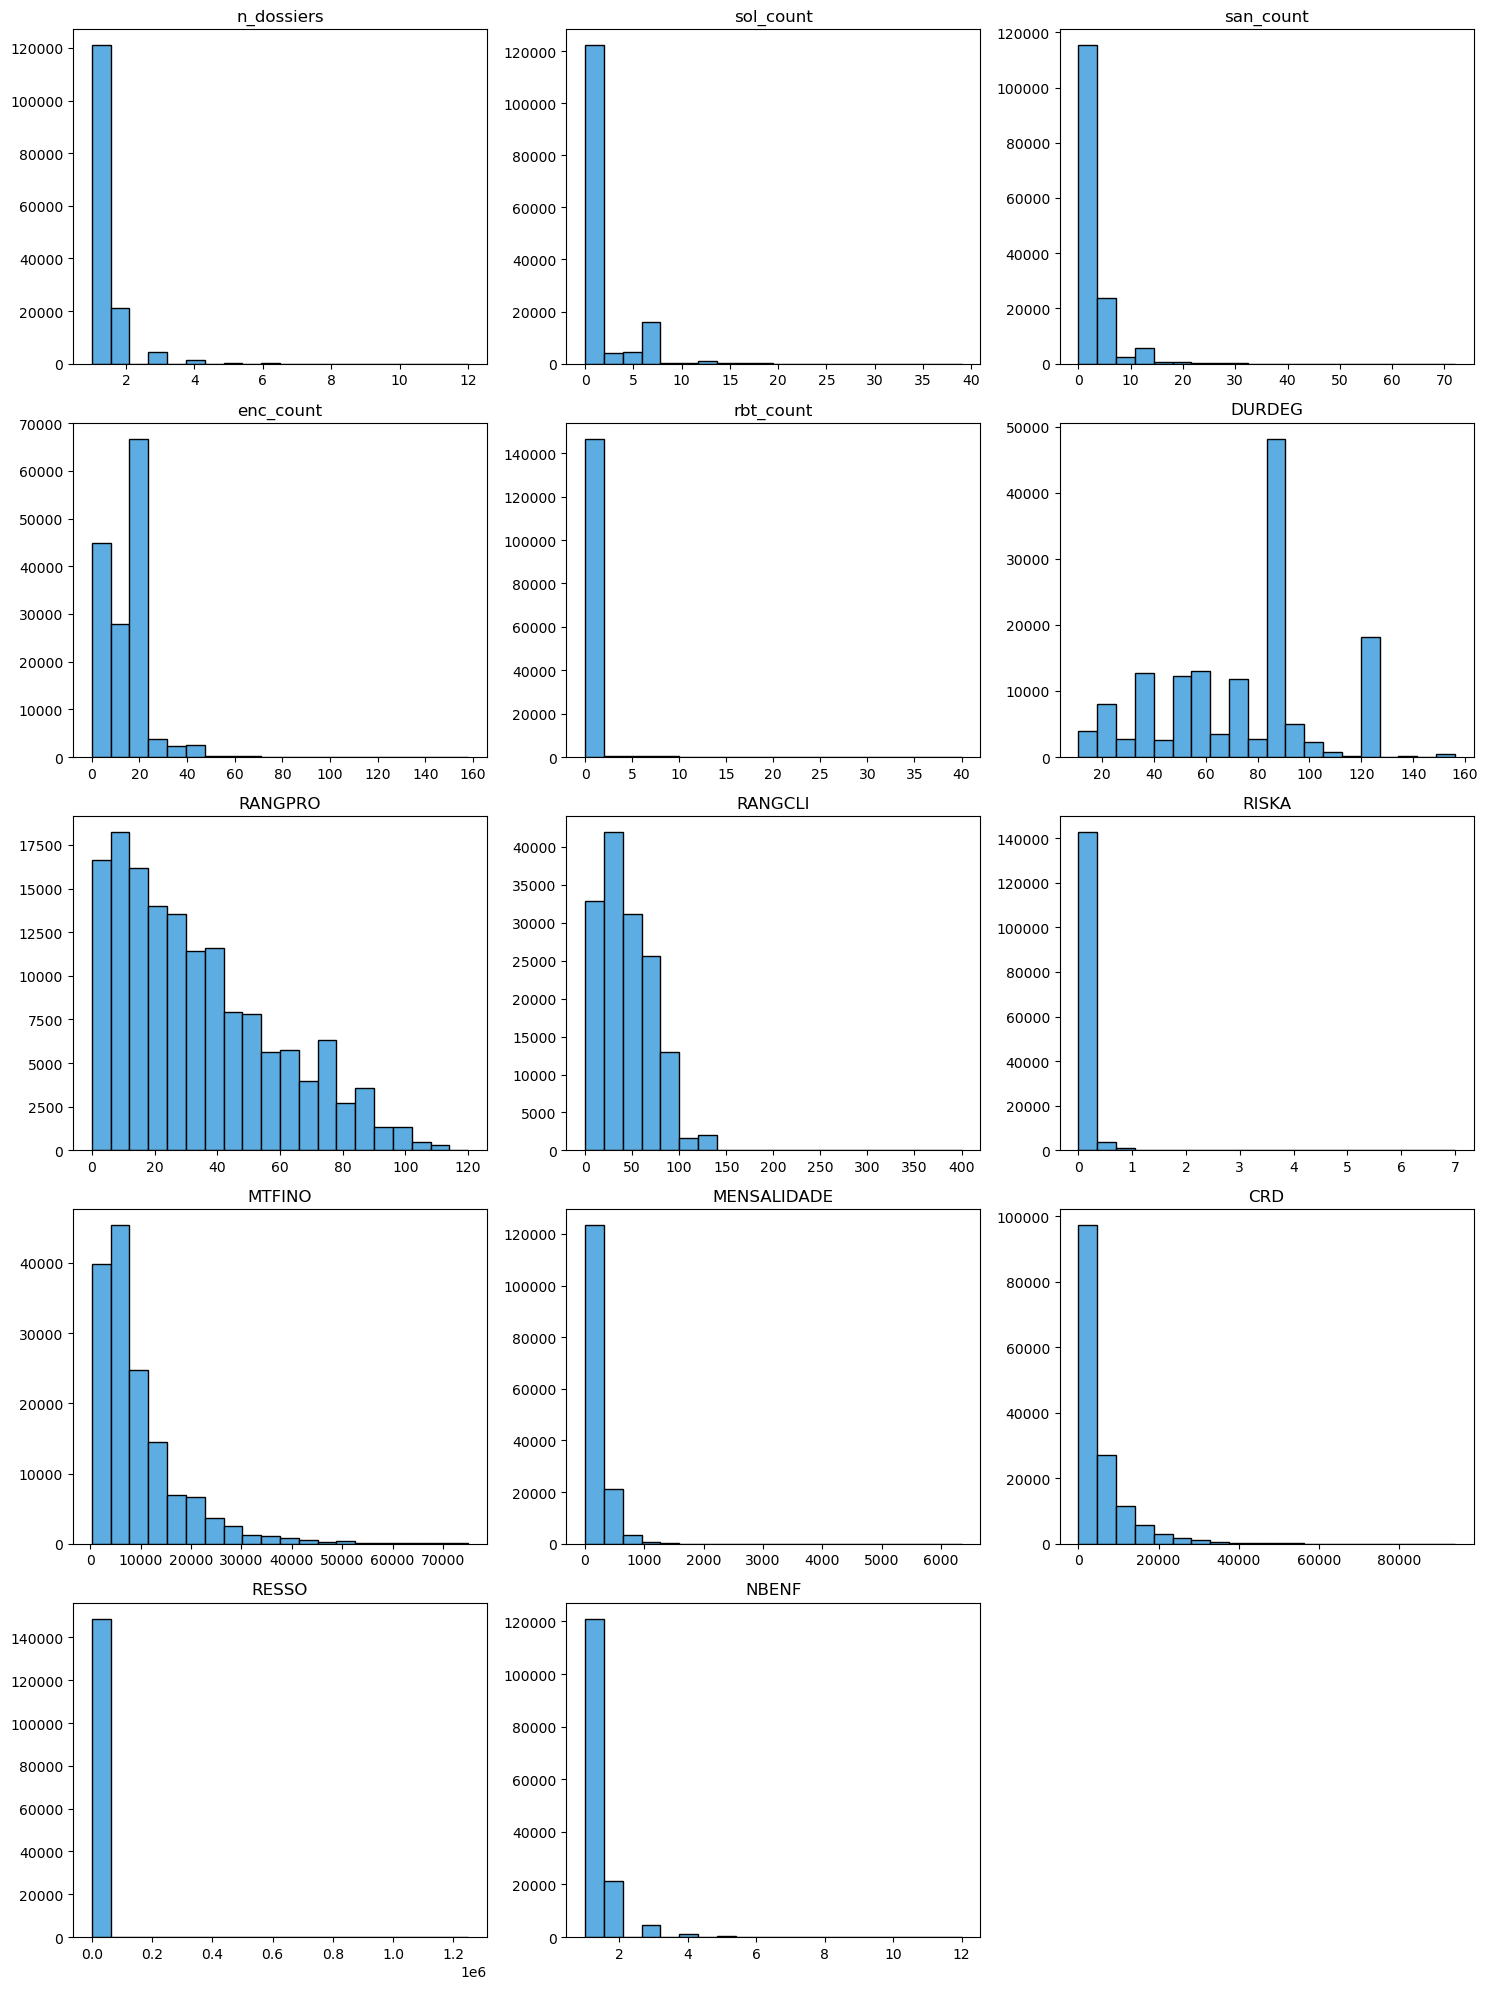

In [ ]:
n = len(num_cols)
fig, axes = plt.subplots(nrows = (n // 3) + 1, ncols = 3, figsize = (15, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(agg_clients_num[col].dropna(), bins = 20, color = '#5dade2', edgecolor = 'black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    #axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Boxplots:**

C:\Users\jcari\AppData\Local\Temp\ipykernel_37900\1031368143.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[feat] = pd.to_numeric(data[feat], errors="coerce")
C:\Users\jcari\AppData\Local\Temp\ipykernel_37900\1031368143.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[feat] = pd.to_numeric(data[feat], errors="coerce")
C:\Users\jcari\AppData\Local\Temp\ipykernel_37900\1031368143.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

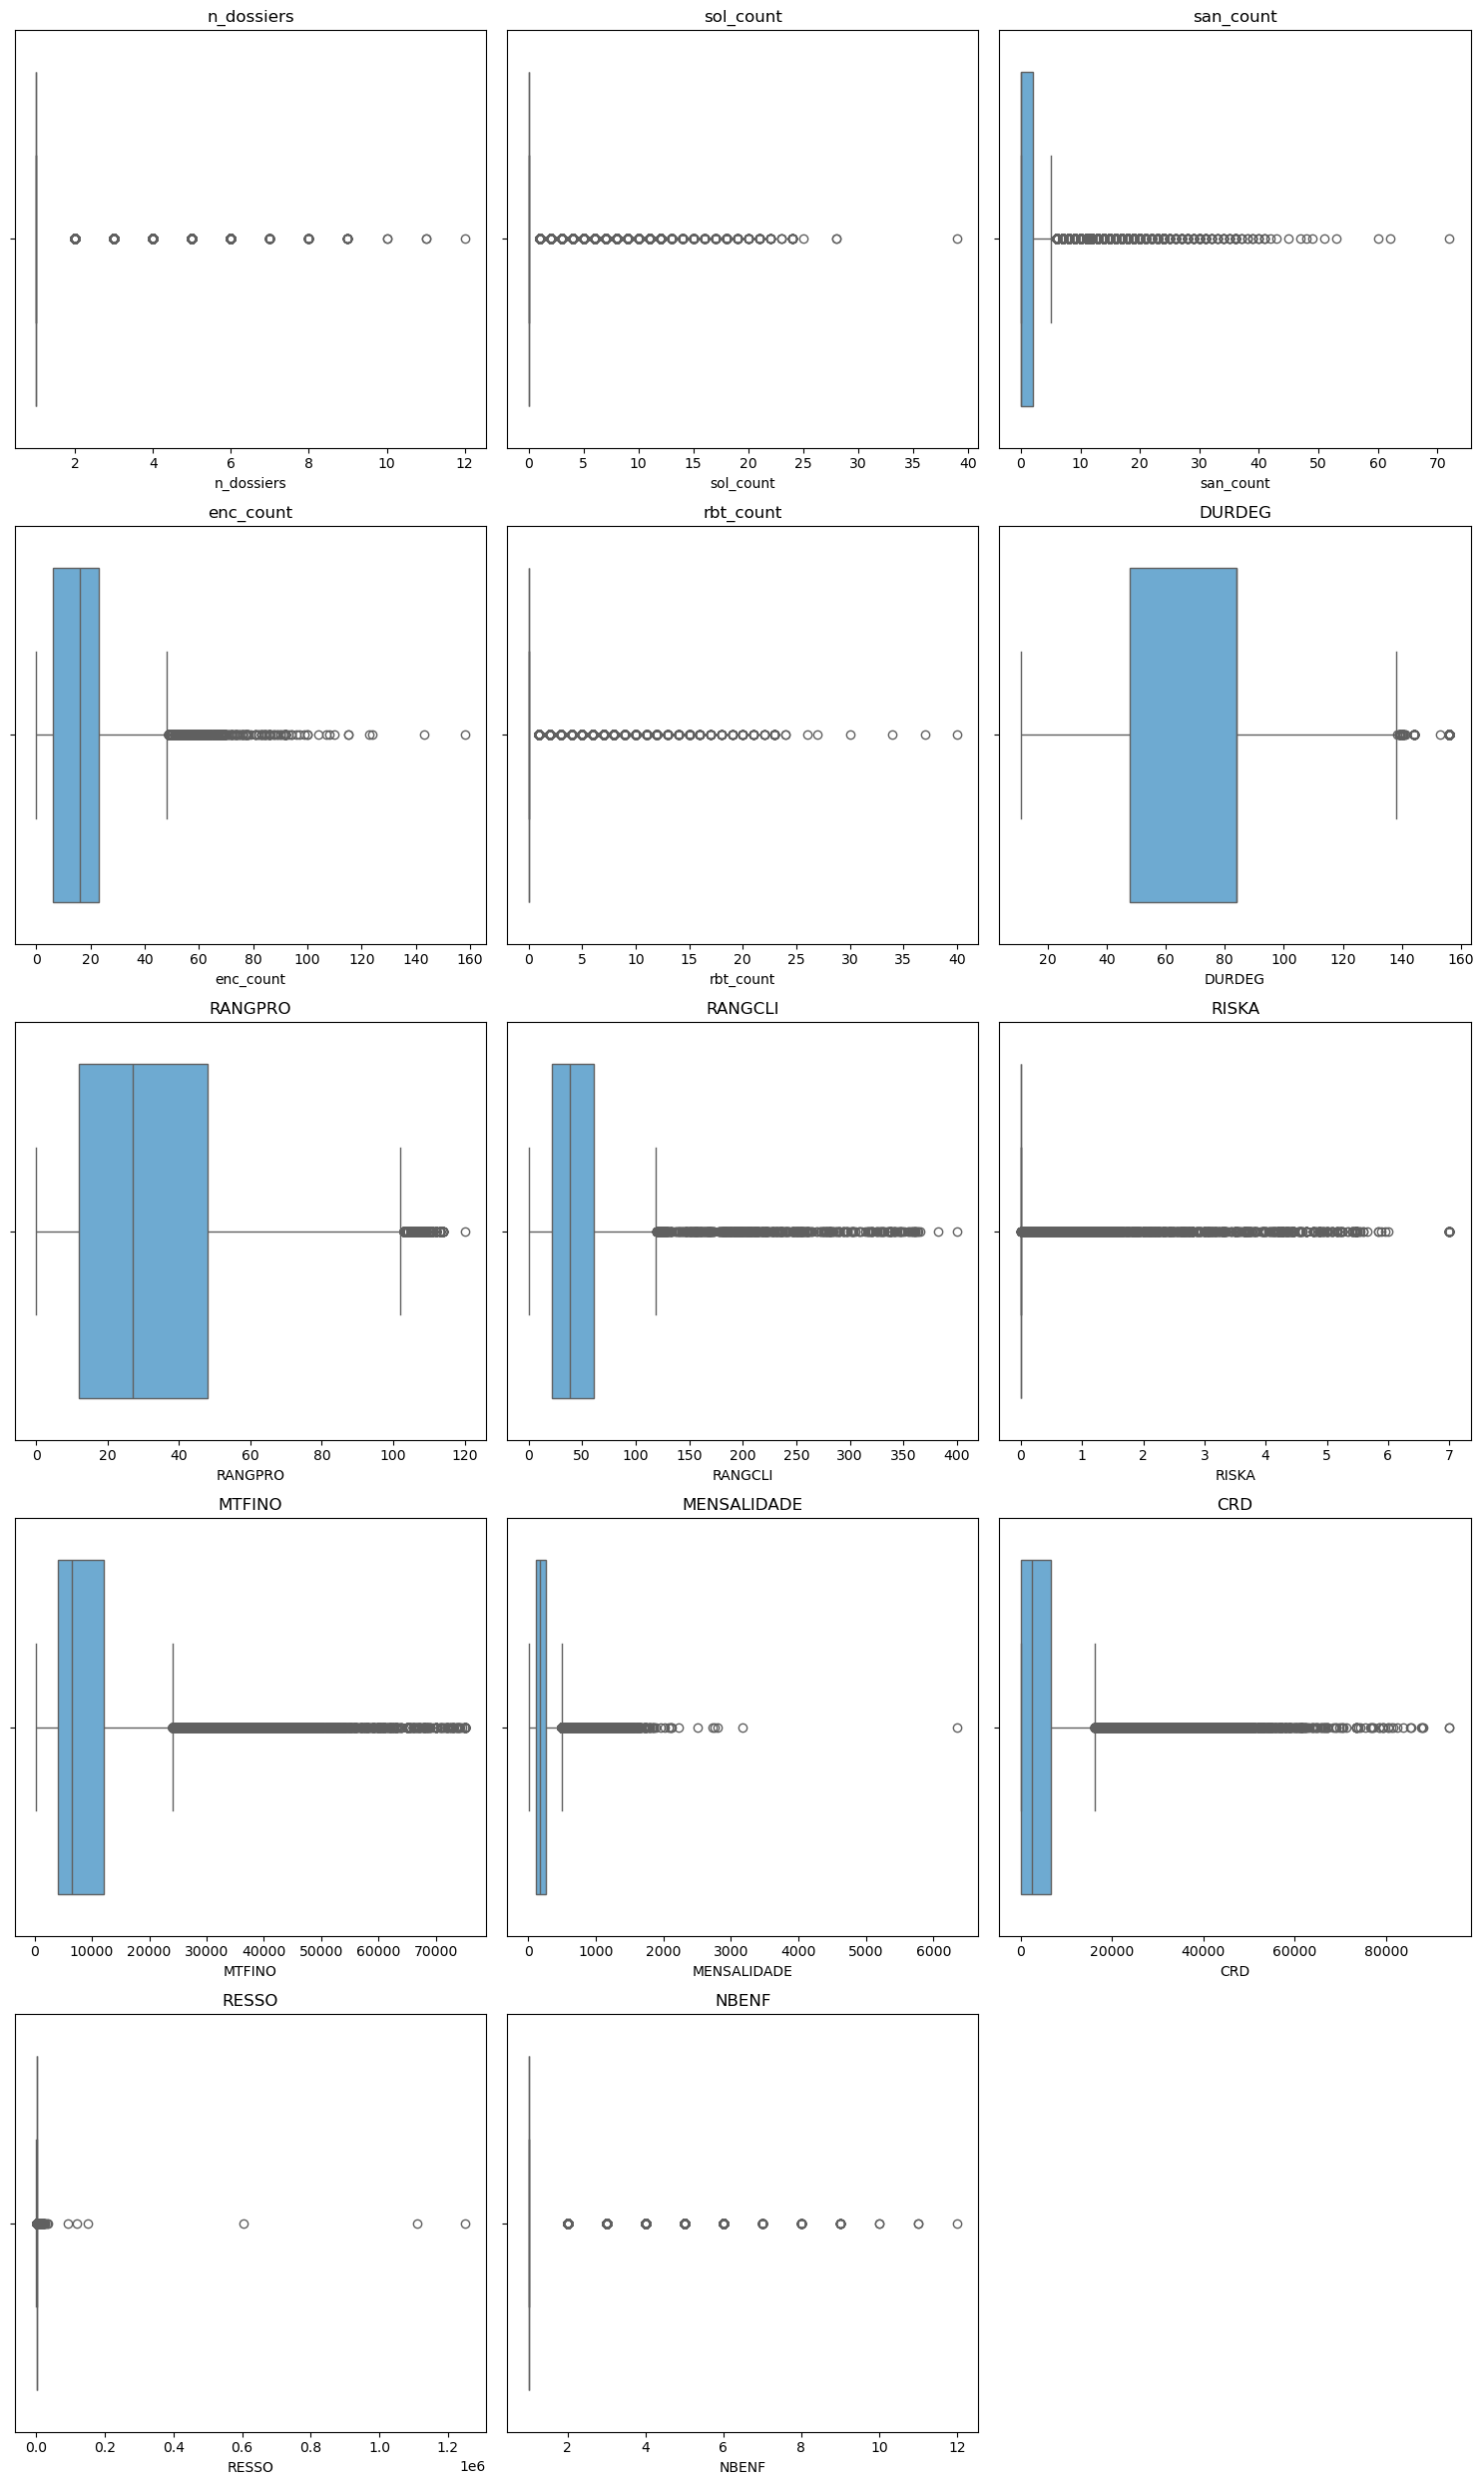

In [ ]:
def plot_multiple_boxplots(data, feats):
    
    n = len(feats)  # número de features
    ncols = 3
    nrows = (n // ncols) + (n % ncols > 0)
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
    axes = axes.flatten()
    
    for i, feat in enumerate(feats):
        # garantir que é numérica
        data[feat] = pd.to_numeric(data[feat], errors="coerce")
        
        # remover NaNs para evitar erro
        clean_data = data[feat].dropna()
        
        if len(clean_data) > 0:
            sns.boxplot(x=clean_data, ax=axes[i], color="#5dade2")
            axes[i].set_title(feat)
        else:
            axes[i].set_visible(False)
    
    # remover eixos extra
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
#    plt.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

plot_multiple_boxplots(agg_clients_num, num_cols)

**Correlation:**

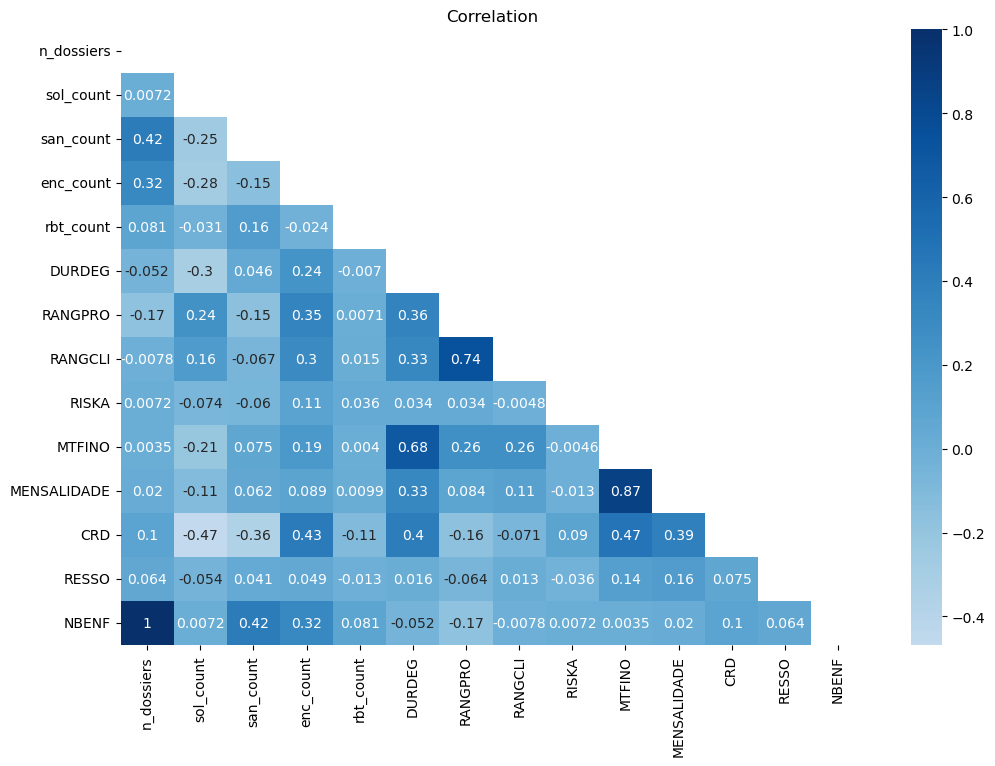

In [ ]:
cor_spearman = agg_clients_num.corr(method ='spearman')
#mask = (cor_spearman.abs() < 0.5)
mask = np.triu(np.ones_like(cor_spearman, dtype=bool))

plt.figure(figsize=(12,8))
sns.heatmap(cor_spearman, 
            annot=True, 
            mask=mask,
            cmap = "Blues", 
            center=0)

plt.title("Correlation")
plt.show()

In [ ]:
agg_clients_num[agg_clients_num['RANGPRO'] == agg_clients_num['RANGCLI']]

,n_dossiers,sol_count,san_count,enc_count,rbt_count,DURDEG,RANGPRO,RANGCLI,RISKA,MTFINO,MENSALIDADE,CRD,RESSO,NBENF
CONTRIB,,,,,,,,,,,,,,
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,1,0,0,23,0,120.0,91.0,91.0,0.0,20000.000,347.447280,8115.247,1113.258,1.0
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,2,12,0,0,0,60.0,21.0,21.0,0.0,9726.555,304.456898,0.000,678.483,2.0
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,1,0,12,0,0,72.0,34.0,34.0,0.0,2500.000,56.017772,0.000,838.186,1.0
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,1,0,0,23,0,84.0,74.0,74.0,0.0,5000.000,100.073575,883.500,1314.144,1.0
000406feeb8088e3b05f47bc89160d25ca14f11c31f91bc6516a4e6753e58d73,1,6,0,0,0,84.0,24.0,24.0,0.0,12000.000,274.916857,0.000,797.805,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffac57dea1d969a42b214d427e4bf6a3832b0733ee218343545bcb8c7d43719,1,0,0,19,0,84.0,34.0,34.0,0.368421,7750.000,149.986502,6240.644,1455.621,1.0
fffb0b5e039cf837e38c5abe51fb5d9db7366c12609d566f8b44ef3f8a12a349,1,0,0,23,0,120.0,59.0,59.0,0.0,12500.000,216.051740,9474.858,957.059,1.0
fffc47b191b25cbc3dbc9ce436b94e52d2084144ee5bec31fd2457f3cff87c3c,1,0,0,7,0,36.0,6.0,6.0,0.142857,2000.000,81.856368,1994.881,0.000,1.0


In the output above we can see that 82009 clients have always kept to date with their payments.

In [ ]:
agg_clients_num[agg_clients_num['rbt_count'] == 40]

,n_dossiers,sol_count,san_count,enc_count,rbt_count,DURDEG,RANGPRO,RANGCLI,RISKA,MTFINO,MENSALIDADE,CRD,RESSO,NBENF
CONTRIB,,,,,,,,,,,,,,
a7694a908823a9d442bc440d46fe935d580c605edcc4057992e852b4f969f6da,3,0,0,26,40,76.0,22.0,61.0,0.0,23950.86,531.20642,9331.144667,2774.367174,3.0


Here, we can see a client who has churned 40 times.

In [ ]:
agg_clients_num[agg_clients_num['rbt_count'] > agg_clients_num['n_dossiers']]

,n_dossiers,sol_count,san_count,enc_count,rbt_count,DURDEG,RANGPRO,RANGCLI,RISKA,MTFINO,MENSALIDADE,CRD,RESSO,NBENF
CONTRIB,,,,,,,,,,,,,,
000ade74e6fc9364ed7c7c759e1ce3b8844e712eb39a7d9530885f4bbc08b046,1,0,17,2,2,84.0,17.0,17.0,0.047619,10000.0,205.735821,0.0000,3081.422333,1.0
004eb27ba7cf84b926c7fc7e61bfa841e1386f1704e440d44c11b037731becf4,2,0,15,14,8,42.0,22.5,33.0,0.035714,2500.0,83.695343,1014.2425,1436.312283,2.0
0069b8ae1d1895c7836d5a9680b96185702aba0a92b93e2b013357ed73fa7154,1,0,6,0,2,60.0,54.0,54.0,0.0,15000.0,398.469774,0.0000,2484.077000,1.0
0077c898b783ffe42dfa87367a77e380a78cbc4b6b358c7290be9341b2f8b94c,1,0,3,13,7,36.0,12.0,12.0,0.043478,2000.0,75.879076,0.0000,1079.225000,1.0
009710a6d1f3941d893764f27602ce90c2a8a0aa326b48448f7b02d64a0e76cc,1,0,0,17,6,84.0,84.0,84.0,0.0,7500.0,164.415407,0.0000,911.059000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ff9913af89cf519a6d5065383f026b09df803bcc6e26ab9674977a115c25f138,1,0,7,8,8,33.0,32.0,32.0,0.0,2500.0,99.425805,0.0000,1455.621000,1.0
ffa9941500cb052fcb3eb1ebeb1bd645db83c7b742de9c918e5a733cab80d75b,1,0,4,13,6,78.0,77.0,77.0,0.0,11000.0,169.424788,0.0000,813.948000,1.0
ffb22f95824305622dacb76daf8e35185e8591535e1f864e8b267c292314ae7e,5,0,13,22,6,28.8,3.4,8.0,0.0,3340.0,142.860778,2263.9466,9929.138168,5.0


In [ ]:
len(agg_clients_num[agg_clients_num['rbt_count'] > agg_clients_num['n_dossiers']]) / len(agg_clients_num) * 100

1.190756342071822

In [ ]:
agg_clients_num['RISKA'].value_counts()

RISKA
0.0         123207
0.043478      3490
0.086957      1331
0.130435       741
0.5            709
             ...  
0.584541         1
3.732517         1
0.630435         1
0.098086         1
0.462121         1
Name: count, Length: 1487, dtype: Int64

**- Categorical Features**

In [ ]:
agg_clients_cat

,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
CONTRIB,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,118.0,P,80.0,P,8600,W
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,120.0,P,80.0,P,2845,A
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,117.0,P,60.0,P,2745,T
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,120.0,N,91.0,P,2855,A
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,118.0,P,80.0,P,2635,W
...,...,...,...,...,...,...
fffc991d73df732084dab58938d520b8a5d8712474fa53902c42190d5b1e0f9b,118.0,P,80.0,P,4400,W
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9adcf1007f61b9a9c4,120.0,P,80.0,P,9560,W
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,117.0,P,80.0,P,2845,A


Before we begin the visualization of our categorical features, we will see their distribution and deal with missing values.

In [ ]:
for col in agg_clients_cat.columns:
    print(agg_clients_cat[col].value_counts())

AGFIN
118.0    65306
117.0    41203
120.0    32209
119.0     8308
525.0     1481
112.0      201
111.0       11
500.0        7
116.0        1
503.0        1
100.0        1
Name: count, dtype: int64
PAGAMENTO
P    146359
N      2369
M         1
Name: count, dtype: int64
CSP
80.0    44349
60.0    31826
70.0    13496
31.0    13122
90.0     5363
74.0     4003
15.0     3713
35.0     3663
56.0     3650
32.0     3458
91.0     3304
20.0     2756
30.0     2654
41.0     2250
92.0     1449
33.0     1209
50.0     1095
10.0      888
54.0      885
81.0      798
86.0      798
57.0      743
55.0      673
52.0      656
40.0      573
58.0      535
53.0      313
34.0      202
25.0      104
96.0       96
99.0       72
0.0        18
51.0       15
Name: count, dtype: int64
NATIO
P    147069
D       889
C       770
X         1
Name: count, dtype: int64
PTT
2735    1750
2910    1716
4430    1619
2725    1527
4435    1404
        ... 
2838       1
6158       1
4424       1
6021       1
1850       1
Name: count,

In [ ]:
agg_clients_cat.isna().sum()

AGFIN             0
PAGAMENTO         0
CSP               0
NATIO             0
PTT               0
MODCONTACTO    5161
dtype: int64

In the output of the cell above, we can see 5161 missing values in MODCONTACT.

In [ ]:
agg_clients_cat['MODCONTACTO'].fillna(agg_clients_cat['MODCONTACTO'].mode()[0], inplace=True)

C:\Users\jcari\AppData\Local\Temp\ipykernel_37900\2262050263.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  agg_clients_cat['MODCONTACTO'].fillna(agg_clients_cat['MODCONTACTO'].mode()[0], inplace=True)
C:\Users\jcari\AppData\Local\Temp\ipykernel_37900\2262050263.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_clients_cat['MODCONTA

We decided to fill these missing values using the feature's mode.

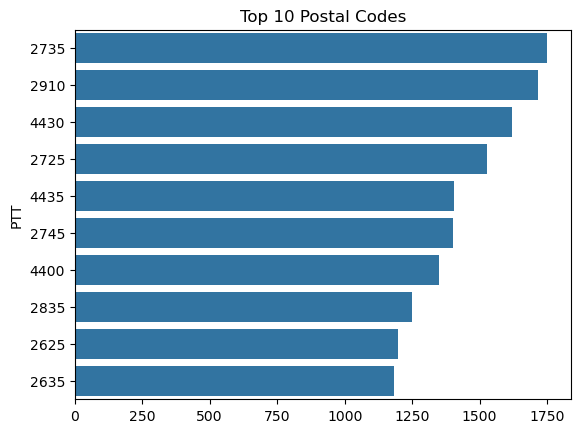

In [ ]:
top_postal = agg_clients_cat['PTT'].value_counts().nlargest(10)

sns.barplot(x = top_postal.values, y = top_postal.index)
plt.title('Top 10 Postal Codes')
plt.show()

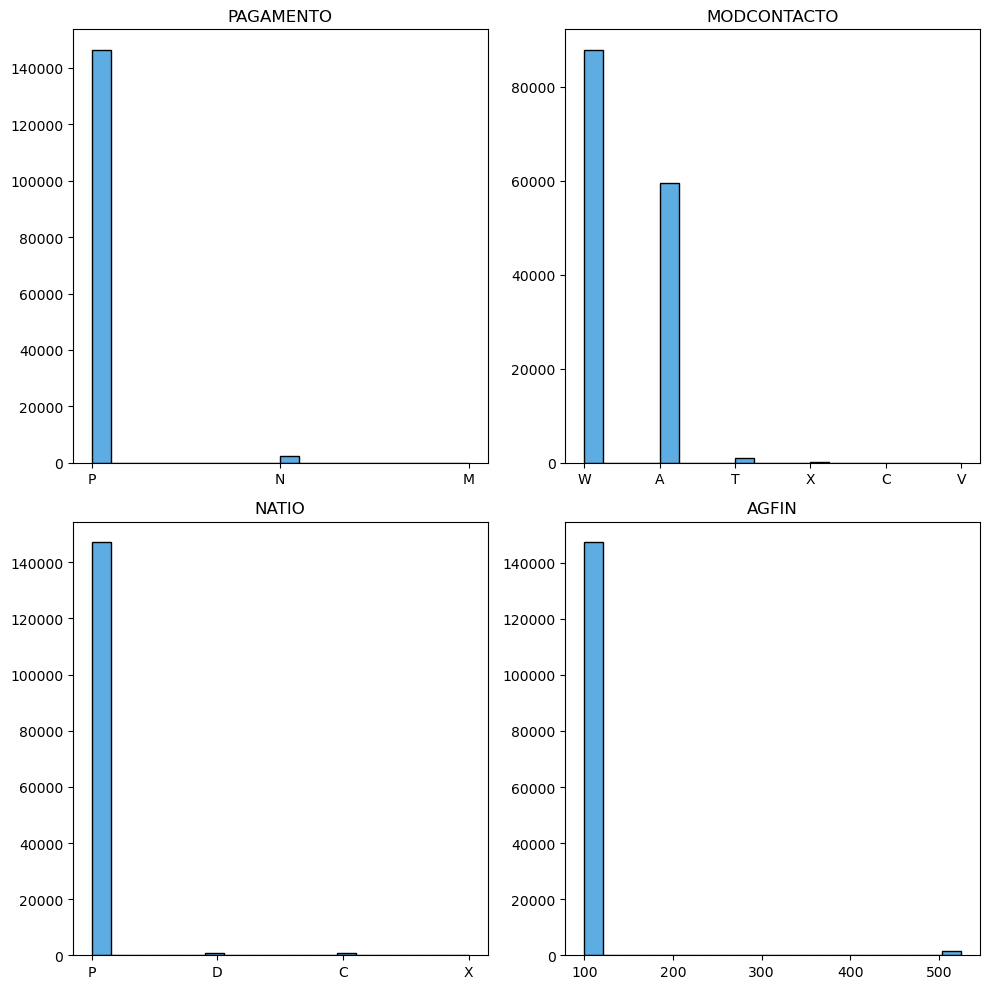

In [ ]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))
axes = axes.flatten()
cols = ['PAGAMENTO', 'MODCONTACTO', 'NATIO', 'AGFIN']
for i, col in enumerate(cols):
    axes[i].hist(agg_clients_cat[col].dropna(), bins = 20, color = '#5dade2', edgecolor = 'black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    #axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

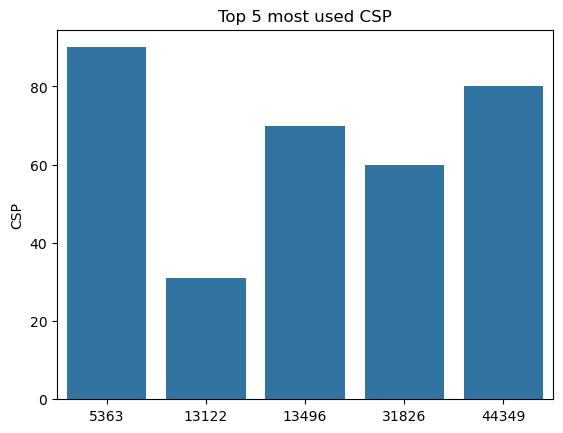

In [ ]:
top_csp = agg_clients_cat['CSP'].value_counts().nlargest(5)

sns.barplot(x = top_csp.values, y = top_csp.index)
plt.title('Top 5 most used CSP')
plt.show()

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# 3. Data Preparation
       
</div>